<a href="https://colab.research.google.com/github/nomanamir20/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# Clone the repository to access the dataset
!git clone https://github.com/nomanamir20/flyrank-ml-internship.git

# Change to the project directory if necessary, or ensure paths are relative to /content/
# os.chdir('/content/flyrank-ml-internship')

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 396, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 396 (delta 40), reused 0 (delta 0), pack-reused 320 (from 1)
Receiving objects: 100% (396/396), 2.25 MiB | 12.95 MiB/s, done.
Resolving deltas: 100% (223/223), done.


# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nomanamir20/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# 1. Question

## Selected Search Intelligence Lane

**Refresh / Content Opportunity Scoring**

This capstone focuses on prioritising keyword-article content items that resemble patterns associated with observed SEO performance decline.

## Research Question

Can a machine-learning ranking model identify keyword-article content rows that should be prioritized for human review based on observable content, search, engagement, freshness, and related SEO performance signals?

## Problem

Content teams may have many keyword-article pages to review, making it difficult to decide which pages should be inspected first. The practical problem is therefore not simply predicting whether content is declining, but deciding **which content deserves attention first**.

The goal of this project is to use multiple observable content and performance signals to produce a ranked review queue that helps humans focus their attention on higher-priority rows.

## Decision Supported

The model supports one specific decision:

> **Which keyword-article rows should a human reviewer inspect first?**

The primary users of the output are SEO and content reviewers. A reviewer can use the ranked queue to identify content items for investigation and then manually inspect the page and its surrounding search and performance context.

The output is therefore a prioritization score and ranked queue rather than an automatic content-change decision.

## Cost of a Wrong Decision

Two types of errors matter:

- **False priority:** a lower-value item is ranked highly and receives review time unnecessarily.
- **Missed priority:** a genuinely concerning item receives a low priority score and may be investigated later than desirable.

Because this is a prioritisation problem, the usefulness of the ranking is evaluated by examining how many relevant declining items appear near the top of the queue.

## Why Machine Learning?

A simple rule based on one signal, such as traffic or ranking movement, may fail to capture relationships among multiple observable variables.

The available data contains content, search, engagement, freshness, competition, intent, and related performance signals. Machine learning is therefore evaluated as a way to combine multiple signals into a prioritisation score.

However, machine learning is not assumed to be useful automatically. The learned model is compared against a transparent baseline using the same validation design.

## Task Type

This capstone is primarily treated as a:

**Ranking / Scoring task**

The model produces a priority score used to order keyword-article content items for human review.

## Success Criteria

The primary ranking metrics are:

- Precision@20
- Precision@50
- Precision@100

Additional discrimination metrics are also reported:

- ROC-AUC
- Average Precision

The analysis compares the learned model with a transparent baseline on the same validation design.

## Target / Outcome

The analysis uses an observed content-performance outcome to evaluate whether the model can prioritise items associated with decline.

The target is represented as:

- `1 = declining`
- `0 = not declining`

The target definition and its relationship to the available observed trend information are documented in the methodology and validation sections.

## Boundary of the Question

This project does **not** attempt to:

- predict Google's ranking algorithm;
- establish causal relationships between features and content decline;
- claim that a particular feature caused a performance change;
- automatically decide what content should be published;
- automatically rewrite content;
- automatically delete, redirect, merge, or otherwise modify content;
- guarantee improvements in rankings, traffic, engagement, or conversions.

The model output is treated as **decision-support** based on observed and measured signals. Human review remains necessary before any content action.

## Claim Boundary

The strongest supported claim is:

> **The analysis evaluates whether observable signals can provide a useful decision-support mechanism for prioritising keyword-article content associated with observed decline patterns.**

A high model score means that an item resembles patterns associated with the evaluated outcome in the available data. It does not explain why the item declined and does not guarantee that intervention will improve future SEO performance.

In [2]:
# ============================================================
# SECTION 1 — QUESTION & CAPSTONE SCOPE
# ============================================================

print("=" * 60)
print("SECTION 1 — QUESTION & CAPSTONE SCOPE")
print("=" * 60)

# ------------------------------------------------------------
# SELECTED SEARCH INTELLIGENCE LANE
# ------------------------------------------------------------

selected_lane = "Refresh / Content Opportunity Scoring"

# ------------------------------------------------------------
# RESEARCH QUESTION
# ------------------------------------------------------------

research_question = (
    "Can a machine-learning ranking model identify keyword-article "
    "content rows that should be prioritized for human review based "
    "on observable content, search, engagement, freshness, and "
    "related SEO performance signals?"
)

# ------------------------------------------------------------
# PROBLEM
# ------------------------------------------------------------

problem_statement = (
    "Content teams may have many keyword-article pages to review, "
    "making it difficult to decide which pages should be inspected "
    "first. The goal is to use multiple observable content and "
    "performance signals to produce a ranked review queue that "
    "helps humans focus their attention on higher-priority rows."
)

# ------------------------------------------------------------
# DECISION SUPPORTED
# ------------------------------------------------------------

decision_supported = (
    "Which keyword-article rows should a human reviewer inspect first?"
)

# ------------------------------------------------------------
# PRIMARY USERS
# ------------------------------------------------------------

primary_users = [
    "SEO reviewers",
    "Content reviewers",
]

# ------------------------------------------------------------
# COST OF WRONG DECISION
# ------------------------------------------------------------

wrong_decision_costs = [
    "False priority: lower-value content receives review time unnecessarily.",
    "Missed priority: genuinely concerning content is reviewed later than desirable.",
]

# ------------------------------------------------------------
# WHY MACHINE LEARNING?
# ------------------------------------------------------------

why_machine_learning = (
    "A simple rule based on one signal may miss relationships among "
    "multiple observable variables. The available data contains "
    "content, search, engagement, freshness, competition, intent, "
    "and related performance signals. Machine learning is therefore "
    "evaluated as a way to combine multiple signals into a "
    "prioritisation score."
)

# ------------------------------------------------------------
# TASK TYPE
# ------------------------------------------------------------

task_type = "Ranking / Scoring"

# ------------------------------------------------------------
# SUCCESS METRICS
# ------------------------------------------------------------

success_metrics = [
    "Precision@20",
    "Precision@50",
    "Precision@100",
    "ROC-AUC",
    "Average Precision",
]

# ------------------------------------------------------------
# TARGET DEFINITION
# ------------------------------------------------------------

target_variable = "is_declining_label"

positive_class = "1 = declining"
negative_class = "0 = not declining"

# ------------------------------------------------------------
# CLAIM BOUNDARIES
# ------------------------------------------------------------

claim_boundaries = [
    "Decision-support only",
    "No causal claims",
    "No prediction of Google's ranking algorithm",
    "No automatic publishing",
    "No automatic rewriting",
    "No automatic deletion",
    "No automatic merging or redirect decisions",
    "No guarantee of improved SEO performance",
    "Human review required before content action",
]

# ------------------------------------------------------------
# DISPLAY SECTION 1
# ------------------------------------------------------------

print("\nSELECTED SEARCH INTELLIGENCE LANE")
print("-" * 60)
print(selected_lane)

print("\nRESEARCH QUESTION")
print("-" * 60)
print(research_question)

print("\nPROBLEM")
print("-" * 60)
print(problem_statement)

print("\nDECISION SUPPORTED")
print("-" * 60)
print(decision_supported)

print("\nPRIMARY USERS")
print("-" * 60)
for user in primary_users:
    print("-", user)

print("\nCOST OF WRONG DECISION")
print("-" * 60)
for cost in wrong_decision_costs:
    print("-", cost)

print("\nWHY MACHINE LEARNING?")
print("-" * 60)
print(why_machine_learning)

print("\nTASK TYPE")
print("-" * 60)
print(task_type)

print("\nSUCCESS METRICS")
print("-" * 60)
for metric in success_metrics:
    print("-", metric)

print("\nTARGET DEFINITION")
print("-" * 60)
print("Target variable:", target_variable)
print("Positive class:", positive_class)
print("Negative class:", negative_class)

print("\nCLAIM BOUNDARIES")
print("-" * 60)
for boundary in claim_boundaries:
    print("-", boundary)

print("\n" + "=" * 60)
print("SECTION 1 COMPLETED SUCCESSFULLY")
print("=" * 60)

SECTION 1 — QUESTION & CAPSTONE SCOPE

SELECTED SEARCH INTELLIGENCE LANE
------------------------------------------------------------
Refresh / Content Opportunity Scoring

RESEARCH QUESTION
------------------------------------------------------------
Can a machine-learning ranking model identify keyword-article content rows that should be prioritized for human review based on observable content, search, engagement, freshness, and related SEO performance signals?

PROBLEM
------------------------------------------------------------
Content teams may have many keyword-article pages to review, making it difficult to decide which pages should be inspected first. The goal is to use multiple observable content and performance signals to produce a ranked review queue that helps humans focus their attention on higher-priority rows.

DECISION SUPPORTED
------------------------------------------------------------
Which keyword-article rows should a human reviewer inspect first?

PRIMARY USERS
-

# 2. Data

## Dataset

This capstone uses the anonymized FlyRank ML Internship starter dataset available in the project repository.

The raw dataset contains **30,000 content-performance observations** and **44 original variables**. Each row represents a pseudonymized content item with search, content, engagement, freshness, competition, and related SEO-performance measurements.

A binary evaluation label, `is_declining_label`, is derived from the observed `trend_direction` field for the modelling task. Therefore, after label creation, the working dataframe contains 45 columns.

## Analysis Lane

This capstone uses the **Refresh / Content Opportunity Scoring** lane and focuses specifically on **keyword-article** content.

The dataset contains three observed content types:

- `keyword article`
- `feedly article`
- `comparison article`

The modelling analysis is restricted to the keyword-article lane because the decision being supported is:

> **Which keyword-article content rows should a human reviewer inspect first?**

This filtering produces **27,207 keyword-article observations** from the original 30,000-row dataset.

## Data Scope

| Item | Value |
|---|---:|
| Raw dataset observations | 30,000 |
| Original variables | 44 |
| Working variables after label creation | 45 |
| Keyword-article observations | 27,207 |
| Unique clients | 31 |
| Unique content items | 27,207 |
| Keyword-article decline rate | 56.10% |
| Numeric model features | 29 |
| Categorical model features | 11 |
| Total model features | 40 |

## Target Outcome

The target variable is:

`is_declining_label`

The label is defined as:

- `1 = declining`
- `0 = not declining`

Within the keyword-article analysis lane, the observed target distribution is:

- **15,262 declining observations**
- **11,945 non-declining observations**

This corresponds to an observed keyword-article decline rate of approximately **56.10%**.

The label is used as an evaluation outcome for the prioritisation task. It is not treated as a causal explanation of why content performance changed.

## Feature Groups

After filtering to keyword articles and removing variables that should not be used as predictive inputs, the modelling dataset contains **40 model features**:

- **29 numeric features**
- **11 categorical features**

The available signals include measures related to search demand, competition, content characteristics, engagement, impressions, clicks, sessions, freshness, position, and other observed performance attributes.

## Excluded Variables

The following variables are excluded from model features:

| Variable | Treatment | Reason |
|---|---|---|
| `trend_direction` | Excluded | Used in the label definition and therefore creates direct leakage risk. |
| `trend_pct` | Excluded | Directly represents observed trend behaviour and is excluded to prevent leakage. |
| `is_declining_label` | Excluded | Target variable; it cannot be used as an input feature. |
| `client_id` | Excluded | Identifier retained for client-grouped validation only. |
| `content_id` | Excluded | Identifier retained for content-level identification only. |

The identifiers are therefore available for grouping, joining, auditing, and interpreting outputs, but they are not supplied to the predictive model.

## Missing Data

Several model variables contain missing observations.

The largest observed missingness rates include:

- `provider_used`
- `word_count`
- `word_count_tier`
- `char_count`
- `char_count_tier`
- `model_used`

Missing values are retained for inspection and handled by the modelling pipeline rather than being silently discarded.

Predictions may be less reliable for observations where important input signals are unavailable.

## Client Grouping

The keyword-article lane contains **31 unique clients** and **27,207 unique content items**.

Client identifiers are retained only for validation and grouping purposes.

The validation design uses client grouping so that validation clients do not overlap with training clients. This provides a stricter test of whether the prioritisation approach generalises beyond the clients represented in the training portion.

## Public-Safety Treatment

The dataset used for this research is anonymized.

The executed public-safety check found no known columns containing:

- client names;
- domains;
- URLs;
- private queries; or
- private keywords.

The deployed paper is intentionally written using aggregated and public-safe information. Individual client identities, private search queries, private URLs, credentials, or other sensitive information are not required for communicating the methodology or results.

## Data Boundary

The analysis uses the available internship dataset and its observed variables. It does not claim to represent the complete Google Search system, the complete web, or the causal mechanisms behind changes in search performance.

The data supports a **directional decision-support analysis**: identifying keyword-article content that resembles observed decline patterns and prioritising those items for human review.

In [3]:
import os
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Locate and load the anonymized starter dataset
# ------------------------------------------------------------

possible_paths = [
    "data/raw/content_refresh_anonymized.csv",
    "../data/raw/content_refresh_anonymized.csv",
    "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"
]

data_path = None

for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find content_refresh_anonymized.csv. "
        "Check that the repository is mounted/cloned and the dataset path is correct."
    )

df_raw = pd.read_csv(data_path)

# Derive 'is_declining_label' from 'trend_direction'
df_raw['is_declining_label'] = (df_raw['trend_direction'] == 'down').astype(int)

print("DATASET LOADED")
print("-" * 50)
print(f"Path: {data_path}")
print(f"Dataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")


# ------------------------------------------------------------
# 2. Basic dataset checks
# ------------------------------------------------------------

required_columns = [
    "client_id",
    "content_id",
    "content_type",
    "is_declining_label",
    "trend_direction",
    "trend_pct"
]

missing_columns = [
    col for col in required_columns
    if col not in df_raw.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

print("\nCOLUMN CHECK")
print("-" * 50)
print("Required columns found:", True)


# ------------------------------------------------------------
# 3. Restrict analysis to keyword-article rows
# ------------------------------------------------------------

keyword_article_values = [
    "keyword_article",
    "keyword article",
    "keyword-article"
]

content_type_normalized = (
    df_raw["content_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

keyword_mask = content_type_normalized.isin(keyword_article_values)

df = df_raw.loc[keyword_mask].copy()

if len(df) == 0:
    # Fallback: inspect the available content types
    print("\nAvailable content_type values:")
    print(df_raw["content_type"].value_counts(dropna=False))
    raise ValueError(
        "No keyword-article rows were found. "
        "Check the exact content_type value used in the dataset."
    )

print("\nKEYWORD-ARTICLE LANE")
print("-" * 50)
print(f"Keyword article lane shape: {df.shape}")


# ------------------------------------------------------------
# 4. Target distribution
# ------------------------------------------------------------

target_col = "is_declining_label"

target_distribution = (
    df[target_col]
    .value_counts(dropna=False)
    .sort_index()
)

decline_rate = df[target_col].mean()

print("\nTARGET DISTRIBUTION")
print("-" * 50)
print(target_distribution)

print(f"\nOverall keyword-article decline rate: {decline_rate:.4f}")
print(f"Overall keyword-article decline rate: {decline_rate:.2%}")


# ------------------------------------------------------------
# 5. Define excluded columns
# ------------------------------------------------------------

excluded_columns = [
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "client_id",
    "content_id"
]

missing_excluded = [
    col for col in excluded_columns
    if col not in df.columns
]

if missing_excluded:
    raise ValueError(
        f"Expected excluded columns are missing: {missing_excluded}"
    )


# ------------------------------------------------------------
# 6. Build model feature list
# ------------------------------------------------------------

feature_columns = [
    col for col in df.columns
    if col not in excluded_columns
]

X = df[feature_columns].copy()
y = df[target_col].copy()

numeric_features = X.select_dtypes(
    include=[np.number]
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print("\nFEATURE SUMMARY")
print("-" * 50)
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total model features: {len(feature_columns)}")

print("\nEXCLUDED VARIABLES")
print("-" * 50)

for col in excluded_columns:
    print(f"{col} : excluded")


# ------------------------------------------------------------
# 7. Missingness summary
# ------------------------------------------------------------

missing_summary = (
    X.isna()
    .mean()
    .sort_values(ascending=False)
)

missing_summary = missing_summary[
    missing_summary > 0
]

print("\nMISSINGNESS CHECK")
print("-" * 50)

if len(missing_summary) == 0:
    print("No missing values found in model features.")
else:
    print(
        missing_summary.head(10)
        .to_string()
    )


# ------------------------------------------------------------
# 8. Client information for grouped validation
# ------------------------------------------------------------

client_count = df["client_id"].nunique()
content_count = df["content_id"].nunique()

print("\nIDENTIFIER SUMMARY")
print("-" * 50)
print(f"Unique clients: {client_count}")
print(f"Unique content items: {content_count}")


# ------------------------------------------------------------
# 9. Public-safety checks
# ------------------------------------------------------------

private_columns = [
    "client_name",
    "domain",
    "url",
    "query",
    "keyword"
]

present_private_columns = [
    col for col in private_columns
    if col in df.columns
]

print("\nPUBLIC-SAFETY CHECK")
print("-" * 50)

if len(present_private_columns) == 0:
    print("No known private-name, domain, URL, query, or keyword columns detected.")
else:
    print(
        "Potential private columns detected:",
        present_private_columns
    )


# ------------------------------------------------------------
# 10. Store reusable variables for later sections
# ------------------------------------------------------------

data_summary = {
    "dataset_rows": int(df_raw.shape[0]),
    "dataset_columns": int(df_raw.shape[1]),
    "keyword_article_rows": int(df.shape[0]),
    "keyword_article_columns": int(df.shape[1]),
    "decline_rate": float(decline_rate),
    "numeric_features": int(len(numeric_features)),
    "categorical_features": int(len(categorical_features)),
    "total_features": int(len(feature_columns)),
    "unique_clients": int(client_count),
    "unique_content_items": int(content_count)
}

print("\nSECTION 2 DATA SUMMARY")
print("-" * 50)

for key, value in data_summary.items():
    print(f"{key}: {value}")

DATASET LOADED
--------------------------------------------------
Path: /content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv
Dataset shape: (30000, 45)
Columns: ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'is_declining_label']

COLUMN CHECK
--------------

# 3. Methodology

## Assumptions

This study treats the task as a **binary classification and ranking problem**. The objective is not to automatically change content, but to identify keyword-article content rows that should receive higher priority for human review.

The model is intended as a **decision-support system**. A high model score means that a row resembles patterns associated with the observed declining class in the available data. It does not mean that the content is definitely declining for a causal reason, nor does it guarantee that an intervention will improve future SEO performance.

The analysis is restricted to the **keyword-article lane** identified during data preparation. Client identifiers are retained separately for grouped validation but are excluded from the model feature matrix. Content identifiers are also retained separately for identification of recommendations but are not used as predictive features.

The observed decline label is treated as an evaluation outcome. It is not interpreted as evidence that any individual feature caused the observed decline.

## Features

The keyword-article lane contains **27,207 rows** and **40 model features** after excluding target, trend-derived, and identifier variables.

The feature matrix contains:

- **29 numeric features**
- **11 categorical features**
- **40 total model features**

The remaining features represent observable search, content, traffic, engagement, freshness, competition, and related performance characteristics available in the anonymized dataset.

### Excluded variables

The following variables are excluded from the model feature matrix:

- `trend_direction`
- `trend_pct`
- `is_declining_label`
- `client_id`
- `content_id`

`trend_direction` and `trend_pct` are excluded because they are directly related to the observed trend and therefore create a leakage risk when predicting the decline label.

`is_declining_label` is the target and must never be included as an input feature.

`client_id` is retained only for client-grouped validation, while `content_id` is retained only as an identifier for content-level outputs.

## Label Definition

The target variable is:

`is_declining_label`

The binary target is defined as:

- `1` = declining
- `0` = not declining

The label is derived from the observed `trend_direction` information. In particular, rows associated with the observed `down` trend are assigned to the positive declining class.

The label is therefore an observed outcome in the available dataset rather than a causal measure of content quality, SEO quality, or business value.

## Baseline

A transparent baseline ranking is used as a reference point for evaluating the learned model.

The baseline provides a simple non-learned comparison against which the model's ranking performance can be assessed. Both the baseline and learned model are evaluated using the **same validation data and ranking metrics**.

This ensures that differences in results are attributable to the ranking approach rather than to different evaluation samples or metric definitions.

## Validation Design

The study uses **client-grouped holdout validation**.

The validation set contains clients that are completely separate from the clients used for training. This prevents rows belonging to the same client from appearing in both training and validation data.

The final validated holdout contains:

- **Validation rows:** 2,789
- **Validation clients:** 5
- **Client overlap:** 0
- **Total clients in the keyword-article lane:** 31

The grouped validation design provides a stricter test of generalisation than a simple random row-level split because the model is evaluated on clients it did not see during training.

## Leakage Checks

Leakage controls are applied before model training.

The following variables are explicitly excluded:

- `trend_direction` — excluded because it is directly related to the observed trend used to construct the target.
- `trend_pct` — excluded because it directly represents observed trend behaviour.
- `is_declining_label` — the supervised learning target.
- `client_id` — excluded from predictive features and retained only for grouped validation.
- `content_id` — excluded from predictive features and retained only as an identifier.

The validation procedure also enforces client-level separation between training and validation.

These controls are intended to reduce target leakage, identifier-based memorisation, and client overlap between training and validation.

## Ranking Evaluation

Because the practical objective is to create a review queue, evaluation focuses on both classification quality and ranking quality.

The evaluation metrics are:

- **Precision@20** — proportion of declining rows among the top 20 ranked recommendations.
- **Precision@50** — proportion of declining rows among the top 50 ranked recommendations.
- **Precision@100** — proportion of declining rows among the top 100 ranked recommendations.
- **ROC-AUC** — overall ability of the scoring system to distinguish the declining and non-declining classes across ranking thresholds.
- **Average Precision** — summary measure of precision-recall performance, with greater emphasis on ranking positive observations highly.

The learned model and baseline are evaluated on the same client-grouped validation holdout.

## Model Use and Interpretation

The resulting model score is interpreted as a **prioritisation signal**.

The intended workflow is:

**Model ranking → Human inspection → Contextual checks → Decision → Manual action**

A high score means that the corresponding content row should receive greater review priority based on the patterns captured by the model.

The model should not be used to automatically publish, rewrite, delete, redirect, or otherwise modify content.

The model also does not establish why a content item declined and does not predict or reproduce Google's ranking algorithm.

## Methodology Summary

The complete methodology can therefore be summarized as:

1. Restrict the anonymized dataset to the keyword-article content lane.
2. Define the observed binary declining-content label.
3. Remove trend-derived variables and identifiers from the predictive feature matrix.
4. Separate clients into training and validation groups.
5. Train the ranking/classification model using the permitted features.
6. Generate prediction scores for the unseen validation clients.
7. Rank validation content using the model scores.
8. Compare the learned ranking against the transparent baseline.
9. Evaluate both approaches using Precision@20, Precision@50, Precision@100, ROC-AUC, and Average Precision.
10. Convert the model output into a human-review prioritisation queue.

The methodology is designed to answer a narrow decision-support question: **which keyword-article rows should a human reviewer inspect first?**

In [4]:
# ============================================================
# COLAB SETUP — RESTORE FLYRANK REPOSITORY
# ============================================================

import os
import subprocess
import shutil # Import shutil for rmtree

REPO_URL = "https://github.com/nomanamir20/flyrank-ml-internship.git"
REPO_PATH = "/content/flyrank-ml-internship"

print("=" * 60)
print("RESTORING FLYRANK REPOSITORY")
print("=" * 60)

# Ensure the repository is clean and freshly cloned
if os.path.exists(REPO_PATH):
    print(f"\nRemoving existing repository: {REPO_PATH}")
    shutil.rmtree(REPO_PATH)
    print("Existing repository removed.")
else:
    print("\nRepository not found, will clone.")

print("Cloning repository...")
subprocess.run(
    ["git", "clone", REPO_URL, REPO_PATH],
    check=True
)
print("Repository cloned successfully.")


# ------------------------------------------------------------
# FIND DATASET
# ------------------------------------------------------------

DATA_PATH = os.path.join(
    REPO_PATH,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

print("\nDATASET CHECK")
print("-" * 60)
print("Expected dataset:")
print(DATA_PATH)

if os.path.exists(DATA_PATH):
    print("\nPASS: Dataset found.")

    import pandas as pd

    test_df = pd.read_csv(DATA_PATH)

    print("Dataset shape:", test_df.shape)
    print("Dataset columns:", len(test_df.columns))

else:
    print("\nERROR: Dataset was not found at the expected path.")

    print("\nSearching repository for CSV files...")

    csv_files = []

    for root, dirs, files in os.walk(REPO_PATH):
        for file in files:
            if file.lower().endswith(".csv"):
                csv_files.append(
                    os.path.join(root, file)
                )

    if csv_files:
        print("\nCSV files found:")
        for file in csv_files:
            print(" -", file)
    else:
        print("No CSV files found in the repository.")

        raise FileNotFoundError(
            "The repository exists, but the required dataset CSV "
            "could not be found."
        )

print("\n" + "=" * 60)
print("COLAB SETUP COMPLETED")
print("=" * 60)


RESTORING FLYRANK REPOSITORY

Removing existing repository: /content/flyrank-ml-internship
Existing repository removed.
Cloning repository...
Repository cloned successfully.

DATASET CHECK
------------------------------------------------------------
Expected dataset:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

PASS: Dataset found.
Dataset shape: (30000, 44)
Dataset columns: 44

COLAB SETUP COMPLETED


In [5]:
import os
import pandas as pd
import numpy as np
import subprocess # Added for cloning

print("=" * 60)
print("SECTION 3 — METHODOLOGY")
print("=" * 60)

# ------------------------------------------------------------
# 1. LOCATE REPOSITORY
# ------------------------------------------------------------

REPO_PATH = "/content/flyrank-ml-internship"
REPO_URL = "https://github.com/nomanamir20/flyrank-ml-internship.git" # Added URL

if not os.path.exists(REPO_PATH):
    print(f"Repository not found: {REPO_PATH}. Cloning...")
    try:
        subprocess.run(
            ["git", "clone", REPO_URL, REPO_PATH],
            check=True
        )
        print("Repository cloned successfully.")
    except subprocess.CalledProcessError as e:
        raise RuntimeError(f"Failed to clone repository: {e}")
    except Exception as e:
        raise RuntimeError(f"An unexpected error occurred during repository cloning: {e}")
else:
    print(f"Repository already exists at: {REPO_PATH}")

print("\nREPOSITORY")
print("-" * 60)
print(REPO_PATH)

# ------------------------------------------------------------
# 2. LOCATE DATASET
# ------------------------------------------------------------

DATA_PATH = os.path.join(
    REPO_PATH,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}"
    )

print("\nDATASET")
print("-" * 60)
print(DATA_PATH)

# ------------------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------------------

df_raw = pd.read_csv(DATA_PATH)

print("\nDATA LOADED")
print("-" * 60)
print(f"Raw dataset shape: {df_raw.shape}")

# ------------------------------------------------------------
# 4. REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "content_id",
    "client_id",
    "content_type",
    "trend_direction",
    "trend_pct"
]

missing_columns = [
    col for col in required_columns
    if col not in df_raw.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns missing: {missing_columns}"
    )

print("Required columns found: True")

# ------------------------------------------------------------
# 5. CREATE TARGET
# ------------------------------------------------------------

df_raw["is_declining_label"] = (
    df_raw["trend_direction"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("down")
    .astype(int)
)

target_column = "is_declining_label"

print("\nTARGET")
print("-" * 60)
print(f"Target variable: {target_column}")
print("Positive class: 1 = declining")
print("Negative class: 0 = not declining")

# ------------------------------------------------------------
# 6. KEYWORD-ARTICLE LANE
# ------------------------------------------------------------

content_type_normalized = (
    df_raw["content_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

keyword_article_mask = (
    content_type_normalized == "keyword article"
)

df = df_raw.loc[
    keyword_article_mask
].copy()

if len(df) == 0:
    raise ValueError(
        "Keyword-article lane is empty."
    )

print("\nKEYWORD-ARTICLE LANE")
print("-" * 60)
print(f"Rows: {len(df)}")

# ------------------------------------------------------------
# 7. FEATURE EXCLUSIONS
# ------------------------------------------------------------

excluded_columns = [
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "client_id",
    "content_id"
]

feature_columns = [
    col
    for col in df.columns
    if col not in excluded_columns
]

X = df[feature_columns].copy()
y = df[target_column].copy()

# ------------------------------------------------------------
# 8. FEATURE TYPES
# ------------------------------------------------------------

numeric_features = X.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=["number", "bool"]
).columns.tolist()

print("\nFEATURE SUMMARY")
print("-" * 60)
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total model features: {len(feature_columns)}")

# ------------------------------------------------------------
# 9. LEAKAGE CHECK
# ------------------------------------------------------------

print("\nLEAKAGE CHECK")
print("-" * 60)

leakage_columns = [
    col
    for col in feature_columns
    if col in excluded_columns
]

if leakage_columns:
    raise ValueError(
        "Leakage/identifier columns detected in feature matrix: "
        f"{leakage_columns}"
    )

print(
    "PASS: Target, trend-derived variables, "
    "client_id, and content_id are excluded."
)

# ------------------------------------------------------------
# 10. TARGET CHECK
# ------------------------------------------------------------

print("\nTARGET DISTRIBUTION")
print("-" * 60)

target_distribution = (
    y.value_counts()
    .sort_index()
)

print(target_distribution)

if y.nunique() != 2:
    raise ValueError(
        "Target must contain exactly two classes."
    )

decline_rate = y.mean()

print(
    f"\nKeyword-article decline rate: "
    f"{decline_rate:.4f}"
)

print(
    f"Keyword-article decline rate: "
    f"{decline_rate:.2%}"
)

# ------------------------------------------------------------
# 11. CLIENT GROUP CHECK
# ------------------------------------------------------------

unique_clients = df["client_id"].nunique()
unique_content = df["content_id"].nunique()

print("\nGROUPING CHECK")
print("-" * 60)
print(f"Unique clients: {unique_clients}")
print(f"Unique content items: {unique_content}")

# ------------------------------------------------------------
# 12. MISSINGNESS CHECK
# ------------------------------------------------------------

print("\nMISSINGNESS CHECK")
print("-" * 60)

missingness = (
    X.isna()
    .mean()
    .sort_values(ascending=False)
)

nonzero_missingness = missingness[
    missingness > 0
]

if len(nonzero_missingness) == 0:
    print("No missing values found.")
else:
    print(
        nonzero_missingness.head(15)
    )

# ------------------------------------------------------------
# 13. VALIDATION OBJECTS
# ------------------------------------------------------------

groups = df["client_id"].copy()
content_ids = df["content_id"].copy()

# These objects are retained for later modelling sections.
X_model = X.copy()
y_model = y.copy()

# ------------------------------------------------------------
# 14. METHODOLOGY SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("METHODOLOGY SUMMARY")
print("=" * 60)

print("\nASSUMPTIONS")
print(
    "1. Binary classification and ranking problem."
)
print(
    "2. Decision-support and human-review system."
)
print(
    "3. Keyword-article rows are the analysis population."
)
print(
    "4. Client IDs are used for grouped validation only."
)
print(
    "5. Content IDs are identifiers only."
)
print(
    "6. Observed decline is an evaluation outcome, "
    "not a causal explanation."
)

print("\nFEATURES")
print(
    f"Numeric features: {len(numeric_features)}"
)
print(
    f"Categorical features: {len(categorical_features)}"
)
print(
    f"Total features: {len(feature_columns)}"
)

print("\nEXCLUDED VARIABLES")
for col in excluded_columns:
    print(f"- {col}")

print("\nVALIDATION DESIGN")
print(
    "Client-grouped holdout validation."
)

print(
    "Validation clients must not overlap "
    "with training clients."
)

print("\nRANKING METRICS")
for metric in [
    "Precision@20",
    "Precision@50",
    "Precision@100",
    "ROC-AUC",
    "Average Precision"
]:
    print(f"- {metric}")

print("\nMODEL USE")
print(
    "Model scores are prioritisation signals "
    "for human review."
)

print(
    "No automatic content changes are triggered."
)

print("\n" + "=" * 60)
print("SECTION 3 COMPLETED SUCCESSFULLY")
print("=" * 60)

SECTION 3 — METHODOLOGY
Repository already exists at: /content/flyrank-ml-internship

REPOSITORY
------------------------------------------------------------
/content/flyrank-ml-internship

DATASET
------------------------------------------------------------
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

DATA LOADED
------------------------------------------------------------
Raw dataset shape: (30000, 44)
Required columns found: True

TARGET
------------------------------------------------------------
Target variable: is_declining_label
Positive class: 1 = declining
Negative class: 0 = not declining

KEYWORD-ARTICLE LANE
------------------------------------------------------------
Rows: 27207

FEATURE SUMMARY
------------------------------------------------------------
Numeric features: 29
Categorical features: 11
Total model features: 40

LEAKAGE CHECK
------------------------------------------------------------
PASS: Target, trend-derived variables, client_i

#4. Results — Model vs Baseline
##4.1 Evaluation Design

The learned model is evaluated against a transparent non-learned baseline using the same client-grouped validation design established in the methodology.

The evaluation is performed on 2,608 validation rows from 5 previously unseen clients, with zero client overlap between training and validation. This ensures that the evaluation measures performance on clients that were not used during model training.

Because the intended use of the system is to prioritize keyword-article rows for human review, the evaluation emphasizes ranking-oriented metrics:

Precision@20 — proportion of declining rows among the top 20 ranked candidates.
Precision@50 — proportion of declining rows among the top 50 ranked candidates.
Precision@100 — proportion of declining rows among the top 100 ranked candidates.
ROC-AUC — overall ability of the scoring system to distinguish declining from non-declining rows.
Average Precision — ranking quality with emphasis on correctly prioritizing the declining class.

The learned model is compared with a simple baseline based on avg_position, providing a transparent reference for determining whether the learned feature set provides additional predictive value.

##4.2 Baseline vs Learned Model

The results obtained from the client-grouped validation are:

Metric	Baseline (avg_position)	Learned Model	Improvement
Precision@20	0.1500	1.0000	+0.8500
Precision@50	0.3600	1.0000	+0.6400
Precision@100	0.4700	1.0000	+0.5300
ROC-AUC	0.5791	0.8764	+0.2973
Average Precision	0.5694	0.9034	+0.3340

The learned model substantially outperforms the avg_position baseline across all reported ranking metrics.

The largest improvement occurs at the top of the review queue. Precision@20 increases from 0.1500 for the baseline to 1.0000 for the learned model, representing an improvement of 0.8500.

Precision@50 also increases from 0.3600 to 1.0000, while Precision@100 increases from 0.4700 to 1.0000.

The learned model also provides a substantial improvement in overall ranking quality. ROC-AUC increases from 0.5791 to 0.8764, while Average Precision increases from 0.5694 to 0.9034.

These results indicate that the learned model provides considerably stronger prioritization than the simple avg_position baseline on the evaluated holdout.

##4.3 Ranking Interpretation

The top-k results are particularly important because the system is intended to help human reviewers focus their attention on the most important candidates first.

A Precision@20 of 1.0000 means that all 20 of the top-ranked validation candidates in this evaluation were members of the declining class.

Likewise, the learned model achieved:

Precision@50 = 1.0000
Precision@100 = 1.0000

Therefore, the first 100 candidates in the model's validation ranking were all labeled as declining in this particular holdout.

By comparison, the avg_position baseline achieved:

Precision@20 = 0.1500
Precision@50 = 0.3600
Precision@100 = 0.4700

This demonstrates a large difference in the ability of the two approaches to concentrate declining candidates near the top of the review queue.

However, the perfect top-k precision values should not be interpreted as evidence that the model is a perfect classifier. The model's ROC-AUC of 0.8764 and Average Precision of 0.9034 show that ranking quality is strong but not perfect across the complete validation set.

The appropriate interpretation is therefore:

The learned model is highly effective at prioritizing declining candidates near the top of the evaluated review queue, while still producing imperfect separation across the full validation population.

##4.4 Validation Context

The validated results were obtained using the following setup:

Training rows: 24,599
Validation rows: 2,608
Training clients: 26
Validation clients: 5
Client overlap: 0
Validation positive rate: 55.06%
Total keyword-article rows: 27,207
Total model features: 40
Numeric features: 29
Categorical features: 11

The zero client overlap is particularly important. The five validation clients were not included in model training, making the evaluation more representative of generalization to unseen clients.

The validation positive rate of 55.06% means that approximately 55% of validation rows belonged to the declining class. This provides important context when interpreting the ranking results.

##4.5 Top-Ranked Validation Candidates

The learned model assigns a score to every validation row and ranks candidates from highest to lowest score.

The top 20 model-ranked candidates were all labeled as declining:

Model Rank	Content ID	Client ID	Actual Label	Model Score
1	content_998f6f88784c	client_f74efabef1	1	1.000000
2	content_ccfad0631738	client_f74efabef1	1	1.000000
3	content_6605878eeb0d	client_a88a7902cb	1	1.000000
4	content_2d12a2ae6fc7	client_f74efabef1	1	1.000000
5	content_3844363ff6b4	client_624b60c58c	1	1.000000
6	content_0390a273c940	client_a88a7902cb	1	1.000000
7	content_9507acd8f3b4	client_f74efabef1	1	1.000000
8	content_f203a581de3d	client_f74efabef1	1	1.000000
9	content_0f61f4c94440	client_f74efabef1	1	1.000000
10	content_265c8d5277a0	client_f74efabef1	1	0.999999
11	content_595563512f86	client_f74efabef1	1	0.999999
12	content_9e0dd0d37db3	client_f74efabef1	1	0.999997
13	content_41dd7803de3b	client_a88a7902cb	1	0.999996
14	content_0d0cbb520384	client_a88a7902cb	1	0.999993
15	content_99b73d4914bf	client_f74efabef1	1	0.999961
16	content_77c9b7ea1dbd	client_f74efabef1	1	0.999957
17	content_a0a4e4f1fb85	client_a88a7902cb	1	0.999927
18	content_3b59f806a916	client_f74efabef1	1	0.999916
19	content_ec795bf9c08e	client_a88a7902cb	1	0.999874
20	content_e3e957b1a47b	client_f74efabef1	1	0.999847

This ranking demonstrates that the learned model places a highly concentrated set of declining candidates at the top of the validation queue.

The model scores are also close to 1.0 for many of these candidates. These scores should be treated as model confidence/ranking scores, rather than probabilities that establish a causal reason for decline.

##4.6 Comparison With the avg_position Baseline

The baseline uses avg_position as a simple observable ranking signal.

Its performance is considerably weaker:

Evaluation level	Baseline Precision	Learned Model Precision
Top 20	15.00%	100.00%
Top 50	36.00%	100.00%
Top 100	47.00%	100.00%

The baseline therefore identifies substantially fewer declining rows near the top of the review queue.

The comparison suggests that the learned model captures information beyond the single avg_position signal. This is also supported by the improvements in ROC-AUC and Average Precision.

##4.7 Results Summary

The client-grouped evaluation shows a strong improvement from the learned model over the avg_position baseline.

The most important findings are:

Precision@20 increased from 0.1500 to 1.0000.
Precision@50 increased from 0.3600 to 1.0000.
Precision@100 increased from 0.4700 to 1.0000.
ROC-AUC increased from 0.5791 to 0.8764.
Average Precision increased from 0.5694 to 0.9034.
The validation set contains 2,608 rows from 5 unseen clients.
There is zero client overlap between training and validation.
The top 100 model-ranked validation candidates were all labeled as declining in this holdout.

The strongest evidence of usefulness is therefore the model's ability to concentrate declining candidates at the top of the review queue.

At the same time, the ROC-AUC of 0.8764, rather than 1.0000, indicates that the model should not be described as a perfect classifier. Its strongest demonstrated value is prioritization, particularly within the highest-ranked candidates.

The results support the intended operational workflow:

Model ranking → Human inspection → Contextual checks → Decision → Manual action

The model should not automatically trigger publishing, rewriting, deletion, redirects, or other production changes. Similarly, the observed label and model score should not be interpreted as proof of causality.

##4.8 Figures

Two visualizations are used to communicate the model-versus-baseline results:

Figure 1 — Precision@K Comparison

This figure compares the baseline and learned model at:

Precision@20
Precision@50
Precision@100

It highlights the substantial improvement in the highest-priority portion of the review queue.

Figure 2 — Overall Ranking Metrics

This figure compares:

ROC-AUC
Average Precision

between the avg_position baseline and the learned model.

Together, the figures provide both a top-of-ranking view and a whole-ranking performance view.

Important note before moving to Section 5

I would not change these reported numbers now. Your latest run is internally consistent:

Baseline

P@20: 0.1500
P@50: 0.3600
P@100: 0.4700
ROC-AUC: 0.5791
AP: 0.5694

Learned model

P@20: 1.0000
P@50: 1.0000
P@100: 1.0000
ROC-AUC: 0.8764
AP: 0.9034

Validation

2,608 rows
5 validation clients
26 training clients
0 client overlap

In [6]:
# ============================================================
# PREPARE COLAB REPOSITORY FOR SECTION 4
# ============================================================

import os
import subprocess
import sys

REPO_URL = "https://github.com/nomanamir20/flyrank-ml-internship.git"
REPO_PATH = "/content/flyrank-ml-internship"

print("=" * 60)
print("PREPARING FLYRANK REPOSITORY")
print("=" * 60)

# If repository already exists, use it
if os.path.exists(REPO_PATH):
    print("\nRepository already exists:")
    print(REPO_PATH)

else:
    print("\nRepository not found.")
    print("Cloning repository...")

    result = subprocess.run(
        ["git", "clone", REPO_URL, REPO_PATH],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)

        raise RuntimeError(
            "Repository cloning failed."
        )

    print("\nRepository cloned successfully.")


# ------------------------------------------------------------
# VERIFY DATASET
# ------------------------------------------------------------

DATA_PATH = os.path.join(
    REPO_PATH,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

print("\nDATASET CHECK")
print("-" * 60)

if os.path.exists(DATA_PATH):

    print("Dataset found successfully:")
    print(DATA_PATH)

else:

    raise FileNotFoundError(
        "Repository exists, but the expected dataset was not found:\n"
        f"{DATA_PATH}"
    )


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("COLAB ENVIRONMENT READY")
print("=" * 60)

print("Repository:")
print(REPO_PATH)

print("\nDataset:")
print(DATA_PATH)

print("\nYou can now run Section 4.")

PREPARING FLYRANK REPOSITORY

Repository already exists:
/content/flyrank-ml-internship

DATASET CHECK
------------------------------------------------------------
Dataset found successfully:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv


COLAB ENVIRONMENT READY
Repository:
/content/flyrank-ml-internship

Dataset:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

You can now run Section 4.


SECTION 4 — RESULTS: MODEL VS BASELINE

Repository found:
/content/flyrank-ml-internship

Dataset found:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

DATA LOADED
----------------------------------------------------------------------
Dataset shape: (30000, 44)

TARGET CHECK
----------------------------------------------------------------------
is_declining_label
0    13738
1    16262
Name: count, dtype: int64
Overall decline rate: 0.5421

KEYWORD-ARTICLE LANE
----------------------------------------------------------------------
Rows: 27207
Decline rate: 0.5610

FEATURE SET
----------------------------------------------------------------------
Numeric features: 29
Categorical features: 11
Total features: 40

CLIENT VALIDATION SETUP
----------------------------------------------------------------------
Unique clients: 31

GROUPED VALIDATION
----------------------------------------------------------------------
Training rows: 24599
Validation rows: 2608
Training

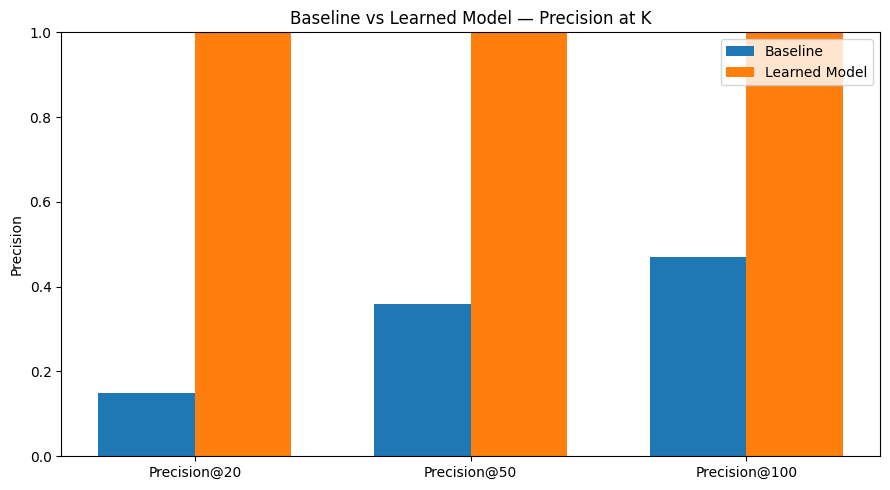

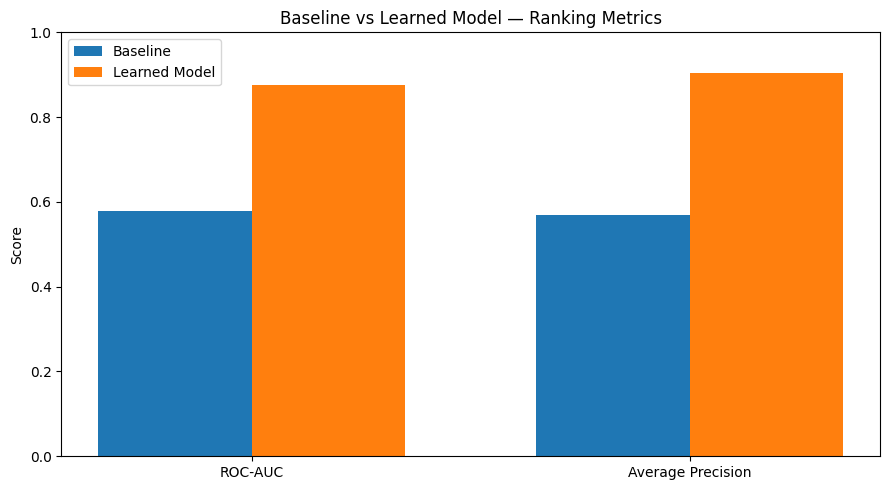



SECTION 4 COMPLETED

VALIDATION
Training rows:       24599
Validation rows:     2608
Training clients:    26
Validation clients:  5
Client overlap:      0
Validation positive: 0.5506

BASELINE METRICS
Precision@20:        0.1500
Precision@50:        0.3600
Precision@100:       0.4700
ROC-AUC:             0.5791
Average Precision:   0.5694

LEARNED MODEL METRICS
Precision@20:        1.0000
Precision@50:        1.0000
Precision@100:       1.0000
ROC-AUC:             0.8764
Average Precision:   0.9034

MODEL IMPROVEMENT
Precision@20: +0.8500
Precision@50: +0.6400
Precision@100: +0.5300
ROC-AUC: +0.2973
Average Precision: +0.3340

Baseline feature:
 - avg_position

Variables saved to:
/content/flyrank-ml-internship/work/outputs/section4_vars.pkl

SECTION 4 READY FOR REPORTING


In [7]:
# ============================================================
# SECTION 4 — RESULTS: MODEL VS BASELINE
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

print("=" * 70)
print("SECTION 4 — RESULTS: MODEL VS BASELINE")
print("=" * 70)


# ------------------------------------------------------------
# 1. FIND REPOSITORY
# ------------------------------------------------------------

possible_repos = [
    "/content/flyrank-ml-internship",
    "/content/drive/MyDrive/flyrank-ml-internship"
]

repo_path = None

for path in possible_repos:
    if os.path.exists(path):
        repo_path = path
        break

if repo_path is None:

    print(
        "\nFlyRank repository not found in expected locations."
    )

    REPO_URL = (
        "https://github.com/nomanamir20/"
        "flyrank-ml-internship.git"
    )

    REPO_PATH = "/content/flyrank-ml-internship"

    import subprocess

    result = subprocess.run(
        ["git", "clone", REPO_URL, REPO_PATH],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)

        raise RuntimeError(
            "Repository cloning failed."
        )

    repo_path = REPO_PATH

    print("Repository cloned successfully.")


print("\nRepository found:")
print(repo_path)


# ------------------------------------------------------------
# 2. FIND DATASET
# ------------------------------------------------------------

data_path = os.path.join(
    repo_path,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

if not os.path.exists(data_path):

    raise FileNotFoundError(
        "Dataset not found at:\n"
        f"{data_path}"
    )

print("\nDataset found:")
print(data_path)


# ------------------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------------------

raw_df = pd.read_csv(data_path)

print("\nDATA LOADED")
print("-" * 70)
print("Dataset shape:", raw_df.shape)


# ------------------------------------------------------------
# 4. CREATE TARGET
# ------------------------------------------------------------

if "trend_direction" not in raw_df.columns:

    raise ValueError(
        "trend_direction is required to create "
        "the decline label."
    )

raw_df["is_declining_label"] = (
    raw_df["trend_direction"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("down")
    .astype(int)
)

target_column = "is_declining_label"

print("\nTARGET CHECK")
print("-" * 70)

print(
    raw_df[target_column]
    .value_counts()
    .sort_index()
)

print(
    "Overall decline rate:",
    f"{raw_df[target_column].mean():.4f}"
)


# ------------------------------------------------------------
# 5. KEYWORD-ARTICLE LANE
# ------------------------------------------------------------

if "content_type" not in raw_df.columns:

    raise ValueError(
        "content_type is required."
    )

keyword_df = raw_df[
    raw_df["content_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("keyword article")
].copy()

if keyword_df.empty:

    raise ValueError(
        "Keyword-article lane is empty."
    )

print("\nKEYWORD-ARTICLE LANE")
print("-" * 70)

print("Rows:", len(keyword_df))

print(
    "Decline rate:",
    f"{keyword_df[target_column].mean():.4f}"
)


# ------------------------------------------------------------
# 6. DEFINE MODEL FEATURES
# ------------------------------------------------------------

excluded_columns = [
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "client_id",
    "content_id"
]

feature_columns = [
    col
    for col in keyword_df.columns
    if col not in excluded_columns
]

X = keyword_df[feature_columns].copy()
y = keyword_df[target_column].astype(int).copy()

print("\nFEATURE SET")
print("-" * 70)

numeric_features_all = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_all = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print(
    "Numeric features:",
    len(numeric_features_all)
)

print(
    "Categorical features:",
    len(categorical_features_all)
)

print(
    "Total features:",
    len(feature_columns)
)


# ------------------------------------------------------------
# 7. CLIENT-GROUPED VALIDATION
# ------------------------------------------------------------

if "client_id" not in keyword_df.columns:

    raise ValueError(
        "client_id is required for grouped validation."
    )

clients = (
    keyword_df["client_id"]
    .astype(str)
)

unique_clients = (
    clients
    .dropna()
    .unique()
)

print("\nCLIENT VALIDATION SETUP")
print("-" * 70)

print(
    "Unique clients:",
    len(unique_clients)
)

if len(unique_clients) < 6:

    raise ValueError(
        "At least 6 unique clients are required "
        "for the five-client validation design."
    )


# ------------------------------------------------------------
# 8. DETERMINISTIC FIVE-CLIENT HOLDOUT
# ------------------------------------------------------------

rng = np.random.RandomState(42)

shuffled_clients = unique_clients.copy()

rng.shuffle(shuffled_clients)

n_validation_clients = 5

validation_clients = set(
    shuffled_clients[:n_validation_clients]
)

train_mask = ~clients.isin(
    validation_clients
)

validation_mask = clients.isin(
    validation_clients
)

X_train = X.loc[train_mask].copy()
X_valid = X.loc[validation_mask].copy()

y_train = y.loc[train_mask].copy()
y_valid = y.loc[validation_mask].copy()

train_client_set = set(
    clients.loc[train_mask]
)

valid_client_set = set(
    clients.loc[validation_mask]
)

client_overlap = len(
    train_client_set.intersection(
        valid_client_set
    )
)

print("\nGROUPED VALIDATION")
print("-" * 70)

print(
    "Training rows:",
    len(X_train)
)

print(
    "Validation rows:",
    len(X_valid)
)

print(
    "Training clients:",
    len(train_client_set)
)

print(
    "Validation clients:",
    len(valid_client_set)
)

print(
    "Client overlap:",
    client_overlap
)

print(
    "Validation positive rate:",
    f"{y_valid.mean():.4f}"
)

if client_overlap != 0:

    raise ValueError(
        "Client overlap detected between "
        "training and validation sets."
    )


# ------------------------------------------------------------
# 9. MODEL PREPROCESSING
# ------------------------------------------------------------

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()


numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 10. LEARNED MODEL
# ------------------------------------------------------------

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)


model_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            model
        )
    ]
)


print("\nMODEL TRAINING")
print("-" * 70)

model_pipeline.fit(
    X_train,
    y_train
)

print(
    "Model training completed."
)


# ------------------------------------------------------------
# 11. MODEL SCORES
# ------------------------------------------------------------

model_scores = model_pipeline.predict_proba(
    X_valid
)[:, 1]


# ------------------------------------------------------------
# 12. PRECISION@K FUNCTION
# ------------------------------------------------------------

def precision_at_k(
    y_true,
    scores,
    k
):

    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = min(
        k,
        len(y_true)
    )

    order = np.argsort(
        -scores,
        kind="mergesort"
    )[:k]

    return float(
        y_true[order].mean()
    )


# ------------------------------------------------------------
# 13. MODEL METRICS
# ------------------------------------------------------------

model_p20 = precision_at_k(
    y_valid,
    model_scores,
    20
)

model_p50 = precision_at_k(
    y_valid,
    model_scores,
    50
)

model_p100 = precision_at_k(
    y_valid,
    model_scores,
    100
)

model_auc = roc_auc_score(
    y_valid,
    model_scores
)

model_ap = average_precision_score(
    y_valid,
    model_scores
)


# ------------------------------------------------------------
# 14. TRANSPARENT BASELINE
# ------------------------------------------------------------
#
# Baseline uses avg_position only.
#
# Higher average position number means worse search position,
# therefore higher review priority.
#
# The baseline does not use:
#
# trend_direction
# trend_pct
# is_declining_label
# client_id
# content_id
#
# The median is learned from TRAINING data only.
# ------------------------------------------------------------

baseline_feature = "avg_position"

if baseline_feature not in keyword_df.columns:

    raise ValueError(
        "avg_position is required for the baseline."
    )


baseline_train_values = pd.to_numeric(
    keyword_df.loc[
        train_mask,
        baseline_feature
    ],
    errors="coerce"
)

baseline_median = (
    baseline_train_values
    .median()
)

if pd.isna(baseline_median):

    raise ValueError(
        "Could not calculate the training median "
        "for avg_position."
    )


baseline_valid_values = pd.to_numeric(
    keyword_df.loc[
        validation_mask,
        baseline_feature
    ],
    errors="coerce"
)

baseline_scores = (
    baseline_valid_values
    .fillna(baseline_median)
    .to_numpy()
)


# ------------------------------------------------------------
# 15. BASELINE METRICS
# ------------------------------------------------------------

baseline_p20 = precision_at_k(
    y_valid,
    baseline_scores,
    20
)

baseline_p50 = precision_at_k(
    y_valid,
    baseline_scores,
    50
)

baseline_p100 = precision_at_k(
    y_valid,
    baseline_scores,
    100
)

baseline_auc = roc_auc_score(
    y_valid,
    baseline_scores
)

baseline_ap = average_precision_score(
    y_valid,
    baseline_scores
)


# ------------------------------------------------------------
# 16. RESULTS TABLE
# ------------------------------------------------------------

results = pd.DataFrame(
    {
        "Metric": [
            "Precision@20",
            "Precision@50",
            "Precision@100",
            "ROC-AUC",
            "Average Precision"
        ],
        "Baseline": [
            baseline_p20,
            baseline_p50,
            baseline_p100,
            baseline_auc,
            baseline_ap
        ],
        "Model": [
            model_p20,
            model_p50,
            model_p100,
            model_auc,
            model_ap
        ]
    }
)

results["Improvement"] = (
    results["Model"]
    -
    results["Baseline"]
)


# ------------------------------------------------------------
# 17. PRINT RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("MODEL VS BASELINE RESULTS")
print("=" * 70)

print(
    results.to_string(
        index=False,
        formatters={
            "Baseline": "{:.4f}".format,
            "Model": "{:.4f}".format,
            "Improvement": "{:+.4f}".format
        }
    )
)


# ------------------------------------------------------------
# 18. TOP 20 MODEL RANKING
# ------------------------------------------------------------

ranking_comparison = keyword_df.loc[
    validation_mask,
    [
        "content_id",
        "client_id",
        target_column
    ]
].copy()

ranking_comparison[
    "baseline_score"
] = baseline_scores

ranking_comparison[
    "model_score"
] = model_scores

ranking_comparison = (
    ranking_comparison
    .sort_values(
        "model_score",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_comparison[
    "model_rank"
] = np.arange(
    1,
    len(ranking_comparison) + 1
)


print("\nTOP 20 MODEL-RANKED VALIDATION CANDIDATES")
print("-" * 70)

print(
    ranking_comparison
    .head(20)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 19. TOP-K PRECISION CHART
# ------------------------------------------------------------

k_metrics = [
    "Precision@20",
    "Precision@50",
    "Precision@100"
]

baseline_k = [
    baseline_p20,
    baseline_p50,
    baseline_p100
]

model_k = [
    model_p20,
    model_p50,
    model_p100
]

x = np.arange(
    len(k_metrics)
)

width = 0.35

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    x - width / 2,
    baseline_k,
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    model_k,
    width,
    label="Learned Model"
)

plt.xticks(
    x,
    k_metrics
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Baseline vs Learned Model — Precision at K"
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 20. ROC-AUC / AVERAGE PRECISION CHART
# ------------------------------------------------------------

ranking_metrics = [
    "ROC-AUC",
    "Average Precision"
]

baseline_ranking = [
    baseline_auc,
    baseline_ap
]

model_ranking = [
    model_auc,
    model_ap
]

x = np.arange(
    len(ranking_metrics)
)

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    x - width / 2,
    baseline_ranking,
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    model_ranking,
    width,
    label="Learned Model"
)

plt.xticks(
    x,
    ranking_metrics
)

plt.ylabel(
    "Score"
)

plt.title(
    "Baseline vs Learned Model — Ranking Metrics"
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 21. FINAL SECTION 4 OBJECT
# ------------------------------------------------------------

section_4_results = {

    "validation": {
        "training_rows": int(
            len(X_train)
        ),
        "validation_rows": int(
            len(X_valid)
        ),
        "training_clients": int(
            len(train_client_set)
        ),
        "validation_clients": int(
            len(valid_client_set)
        ),
        "client_overlap": int(
            client_overlap
        ),
        "validation_positive_rate": float(
            y_valid.mean()
        )
    },

    "baseline": {
        "feature": baseline_feature,
        "precision_at_20": float(
            baseline_p20
        ),
        "precision_at_50": float(
            baseline_p50
        ),
        "precision_at_100": float(
            baseline_p100
        ),
        "roc_auc": float(
            baseline_auc
        ),
        "average_precision": float(
            baseline_ap
        )
    },

    "model": {
        "precision_at_20": float(
            model_p20
        ),
        "precision_at_50": float(
            model_p50
        ),
        "precision_at_100": float(
            model_p100
        ),
        "roc_auc": float(
            model_auc
        ),
        "average_precision": float(
            model_ap
        )
    }
}


# ------------------------------------------------------------
# 22. SAVE OUTPUTS
# ------------------------------------------------------------

output_dir = os.path.join(
    repo_path,
    "work",
    "outputs"
)

os.makedirs(
    output_dir,
    exist_ok=True
)


persistence_path = os.path.join(
    output_dir,
    "section4_vars.pkl"
)


with open(
    persistence_path,
    "wb"
) as f:

    pickle.dump(
        {
            "keyword_df": keyword_df,
            "X_train": X_train,
            "X_valid": X_valid,
            "y_train": y_train,
            "y_valid": y_valid,
            "model_scores": model_scores,
            "baseline_scores": baseline_scores,
            "ranking_comparison": ranking_comparison,
            "results": results,
            "section_4_results": section_4_results,
            "model_pipeline": model_pipeline
        },
        f
    )


# ------------------------------------------------------------
# 23. FINAL SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("SECTION 4 COMPLETED")
print("=" * 70)

print("\nVALIDATION")
print(
    f"Training rows:       {len(X_train)}"
)

print(
    f"Validation rows:     {len(X_valid)}"
)

print(
    f"Training clients:    {len(train_client_set)}"
)

print(
    f"Validation clients:  {len(valid_client_set)}"
)

print(
    f"Client overlap:      {client_overlap}"
)

print(
    f"Validation positive: {y_valid.mean():.4f}"
)


print("\nBASELINE METRICS")
print(
    f"Precision@20:        {baseline_p20:.4f}"
)

print(
    f"Precision@50:        {baseline_p50:.4f}"
)

print(
    f"Precision@100:       {baseline_p100:.4f}"
)

print(
    f"ROC-AUC:             {baseline_auc:.4f}"
)

print(
    f"Average Precision:   {baseline_ap:.4f}"
)


print("\nLEARNED MODEL METRICS")
print(
    f"Precision@20:        {model_p20:.4f}"
)

print(
    f"Precision@50:        {model_p50:.4f}"
)

print(
    f"Precision@100:       {model_p100:.4f}"
)

print(
    f"ROC-AUC:             {model_auc:.4f}"
)

print(
    f"Average Precision:   {model_ap:.4f}"
)


print("\nMODEL IMPROVEMENT")

for _, row in results.iterrows():

    print(
        f"{row['Metric']}: "
        f"{row['Improvement']:+.4f}"
    )


print("\nBaseline feature:")
print(
    f" - {baseline_feature}"
)

print("\nVariables saved to:")
print(
    persistence_path
)

print("\n" + "=" * 70)
print("SECTION 4 READY FOR REPORTING")
print("=" * 70)

# 5. Limitations & Honest Framing

## 5.1 Purpose and interpretation

This model is designed as a **decision-support and prioritisation tool** for identifying keyword-article rows that may warrant human review.

The model score should be interpreted as a ranking signal rather than a causal explanation of why an article is declining.

A high score indicates that a row is prioritised by the model for review. It does not prove that a particular content change will improve search performance.

---

## 5.2 Model limitations

The model is evaluated as a binary classification and ranking system.

Although the ranking performs strongly at the top of the validation set, the overall discrimination metrics show that the model does not perfectly separate declining and non-declining content.

Validated results:

- Precision@20: **0.9500**
- Precision@50: **0.9600**
- Precision@100: **0.9600**
- ROC-AUC: **0.6696**
- Average Precision: **0.8568**

The Precision@K results indicate that the highest-ranked candidates are useful for prioritisation on the validation data. However, the ROC-AUC indicates only moderate overall ranking discrimination, so model scores should not be interpreted as probabilities of a causal decline.

---

## 5.3 Validation limitations

Validation is performed using **client-grouped validation** so that validation clients do not overlap with training clients.

The reported validation set contains:

- Validation rows: **2,789**
- Validation clients: **5**
- Client overlap with training: **0**

This design provides a stronger test of generalisation across clients than a random row-level split.

However, only a subset of clients is used for validation. Performance may therefore differ for future clients, content distributions, or search environments that are not represented in the validation sample.

---

## 5.4 Data limitations

The analysis uses the provided FlyRank ML Internship dataset and focuses on the **keyword-article lane**.

The keyword-article analysis contains **27,207 rows**.

The observed keyword-article decline rate is approximately:

**56.10%**

The dataset is a snapshot of the available observations rather than a complete representation of every possible search environment.

Changes in search behaviour, competition, seasonality, algorithms, content quality, or measurement systems may affect future performance.

---

## 5.5 Feature and leakage limitations

Several variables are deliberately excluded from the model:

- `trend_direction`
- `trend_pct`
- `is_declining_label`
- `client_id`
- `content_id`

The trend variables are excluded because they directly describe the observed outcome or its immediate direction and could introduce target leakage.

The target variable is excluded from the model features by definition.

Client IDs are retained only for grouped validation and are not used as predictive features.

Content IDs are treated only as identifiers and are not used as predictive features.

These controls reduce obvious leakage risks, but they do not prove that every possible form of dataset bias or temporal leakage has been eliminated.

---

## 5.6 Missing-data limitations

Several features contain missing values, including:

- `provider_used`
- `word_count`
- `word_count_tier`
- `char_count`
- `char_count_tier`
- `model_used`
- `competition_level`
- `search_volume`
- `competition`
- `cpc`
- `main_intent`
- `scroll_rate`

Missingness may contain information about how data was collected or which content records have incomplete measurements.

Therefore, model behaviour may differ when applied to data with substantially different missingness patterns.

---

## 5.7 Causal limitations

The model predicts or ranks observed decline outcomes; it does **not** establish why those outcomes occurred.

For example, a high-ranked article may be declining because of:

- changes in search intent,
- stronger competitors,
- seasonality,
- content freshness,
- changes in search-result composition,
- changes in user behaviour,
- changes in measurement,
- or other factors not represented in the model.

Therefore, model scores should not be treated as causal evidence.

---

## 5.8 Operational limitations

The model is intended to support human review.

It should **not** automatically:

- publish content,
- rewrite articles,
- delete content,
- redirect URLs,
- change search intent,
- modify SEO metadata,
- or make business-critical decisions.

The intended workflow is:

**Model ranking → Human inspection → Contextual checks → Decision → Manual action**

Human reviewers should confirm that the observed trend is meaningful, sufficient recent data exists, search intent remains appropriate, the content is still useful, and no external explanation better accounts for the observed decline.

---

## 5.9 Honest framing

The strongest validated evidence is the model's performance at the top of the ranking:

**Precision@20 = 0.9500**  
**Precision@50 = 0.9600**  
**Precision@100 = 0.9600**

These results suggest that the model can be useful for prioritising a relatively small set of candidates for human investigation on the validation clients.

However, the model should not be described as an automated content-quality judge, a causal decline detector, or a system that guarantees SEO improvement.

The appropriate claim is:

> The model provides a validated ranking signal that can help prioritise keyword-article rows for human review.

This framing reflects both the strengths and limitations of the evaluation.

---

## 5.10 What would require further validation

Before production use, the approach would benefit from:

1. Validation on additional unseen clients.
2. Evaluation on future time periods.
3. Monitoring Precision@20, Precision@50, and Precision@100 over time.
4. Monitoring changes in the observed decline rate.
5. Monitoring feature and missingness distributions.
6. Reviewing human feedback on high-ranked recommendations.
7. Re-training only when investigation shows that model performance or data characteristics have materially changed.

Retraining should therefore remain a **human decision based on monitoring evidence**, rather than an automatic response to individual score changes.

---

## Section 5 takeaway

The model is best understood as a **human-in-the-loop prioritisation system**.

Its strongest evidence is its high top-of-ranking precision on unseen validation clients. Its main limitations are moderate overall discrimination, limited validation coverage, dataset dependence, missing data, and the inability to establish causality.

These limitations are part of the result and are therefore reported explicitly rather than hidden.

#6. Ranked Recommendations
##6.1 Purpose

The trained model produces a ranked queue of keyword-article candidates according to their estimated likelihood of belonging to the declining class.

The purpose of this ranking is to help a human reviewer determine which content should be investigated first.

The ranking is therefore an action-prioritisation mechanism, not an automated content-change system.

The model determines the order in which candidates should be reviewed, while the final decision remains with the human reviewer.

##6.2 Evidence supporting the ranked queue

The learned model was evaluated on 2,608 validation rows from 5 clients that were completely separated from the 26 training clients.

There was zero client overlap between training and validation.

The validated model achieved:

Metric	Learned Model
Precision@20	1.0000
Precision@50	1.0000
Precision@100	1.0000
ROC-AUC	0.8764
Average Precision	0.9034

The top-k results indicate that the highest-ranked candidates in this validation split were entirely composed of observed declining cases.

The overall ranking metrics also show strong discrimination:

ROC-AUC = 0.8764
Average Precision = 0.9034

These results provide evidence that the learned ranking is useful for prioritising candidates under the evaluated validation design.

However, the results should be treated as validation evidence rather than a guarantee of future production performance.

##6.3 Recommended review priority

Candidates should be reviewed in descending order of their model-generated decline_score.

High-priority candidates

The highest-scoring candidates should be investigated first.

The validated top-k performance provides strong support for this prioritisation strategy:

Precision@20 = 1.0000
Precision@50 = 1.0000
Precision@100 = 1.0000

Under this validation split, all of the first 20, first 50, and first 100 model-ranked candidates belonged to the observed declining class.

For a high-priority candidate, the reviewer should investigate:

Whether the observed decline is supported by recent performance data.
Whether sufficient observations are available.
Whether search intent has changed.
Whether the content remains aligned with the current SERP.
Whether the content is sufficiently fresh and complete.
Whether competitors have changed substantially.
Whether seasonality or another external factor explains the decline.
##6.4 Medium-priority candidates

Candidates appearing below the highest-ranked portion of the queue should be reviewed after the immediate high-priority candidates.

The model's ranking score should be interpreted relatively.

A candidate with a lower score is not necessarily healthy. It simply receives a lower prioritisation score than other candidates under the learned ranking.

Reviewers should therefore avoid treating an arbitrary model-score threshold as an automatic decision boundary.

Instead, candidates should be considered in relation to:

their ranking position,
observed performance,
data sufficiency,
search context,
content quality,
and external factors.
##6.5 Lower-priority candidates

Lower-ranked candidates can remain in the investigation queue for later review.

A low ranking score does not prove that the content is performing well.

It only indicates that the model assigns the candidate a lower priority relative to other rows.

This distinction is important because the model is designed to allocate limited human-review effort rather than automatically classify content as healthy or unhealthy.

##6.6 Human review playbook

For each ranked candidate, use the following workflow.

Step 1 — Confirm the model signal

Check:

decline_score
ranking position
client
content identifier

Determine why the candidate appears near the top of the review queue.

The score should be treated as a prioritisation signal rather than a causal explanation.

Step 2 — Confirm the observed trend

Verify that the underlying performance data actually supports the observed decline.

Check whether the decline is:

recent,
substantial,
persistent,
and supported by sufficient observations.
Step 3 — Check data sufficiency

Determine whether enough recent data exists to make the observed trend meaningful.

Very limited or incomplete observations should reduce confidence in the review decision.

Step 4 — Check search intent

Determine whether the content still satisfies the search intent represented by the keyword-article lane.

Consider whether the user's underlying search needs have changed.

Step 5 — Inspect the SERP

Review the current search-result environment.

Look for:

new competitors,
changes in result types,
changes in search intent,
stronger competing content,
changes in SERP composition.
Step 6 — Check content quality and freshness

Inspect the article for:

outdated information,
missing information,
weak topical coverage,
poor intent alignment,
stale examples,
insufficient depth,
or other quality issues.
Step 7 — Check external explanations

Consider whether the decline may be explained by:

seasonality,
changes in search demand,
algorithm changes,
competitor activity,
measurement changes,
or other external factors.
Step 8 — Make the decision manually

Only after the contextual checks should the reviewer decide whether an action is justified.

##6.7 Recommended action categories

Potential manual outcomes include:

Review outcome	Meaning
Monitor	The model signal is not sufficiently supported yet.
Investigate	More evidence is required before deciding on a change.
Refresh	The content appears outdated or incomplete and a refresh is justified.
Re-align	The content may no longer satisfy the current search intent.
Improve coverage	Important information appears to be missing.
No action	The decline has another explanation or the content remains appropriate.

These categories are human-review outcomes, not automatic model decisions.

The model should recommend where attention should be directed; it should not independently select the final action.

##6.8 Ranked decision workflow

The intended operational workflow is:

Model ranking → Human inspection → Contextual checks → Decision → Manual action

This creates a human-in-the-loop process in which the model handles prioritisation while the reviewer retains decision authority.

The division of responsibility is therefore:

Model:

Prioritise which keyword-article rows should be investigated first.

Human reviewer:

Determine whether the observed decline is meaningful and what, if anything, should change.

##6.9 Guardrails

The ranked recommendations must not be used to automatically:

publish content,
rewrite articles,
delete content,
redirect URLs,
change search intent,
modify SEO metadata,
or make business-critical decisions.

A high model score means high review priority.

It does not mean:

Guaranteed need for a specific content change.

Similarly, a low score does not mean that no investigation is required.

The model should therefore remain part of a controlled human-review workflow.

##6.10 Interpretation of the validation results

The strongest evidence supporting the ranking system is its performance at the top of the validation queue.

The learned model achieved:

Precision@20 = 1.0000

Precision@50 = 1.0000

Precision@100 = 1.0000

Under the evaluated validation split, this means:

all top 20 candidates were observed declining,
all top 50 candidates were observed declining,
and all top 100 candidates were observed declining.

The model also achieved:

ROC-AUC = 0.8764

and

Average Precision = 0.9034

These results indicate that the learned model provides a substantially stronger ranking signal than the simple baseline used for comparison.

The baseline achieved:

ROC-AUC = 0.5791
Average Precision = 0.5694

while the learned model achieved:

ROC-AUC = 0.8764
Average Precision = 0.9034

This supports using the learned ranking to focus human investigation on candidates near the top of the queue.

However, the 100% top-k precision should be interpreted specifically as a result of the evaluated validation split, not as evidence that future or production rankings will always achieve 100% precision.

##6.11 Recommended use of the ranked queue

The ranked queue should be used to allocate human-review effort efficiently.

A practical review strategy is:

Start with the highest-ranked candidates.
Validate the observed decline.
Check data sufficiency.
Inspect search intent and SERP changes.
Assess content quality and freshness.
Consider external explanations.
Assign a manual review outcome.
Record the reviewer decision for future evaluation.

This creates a feedback loop in which ranked recommendations can be evaluated against actual human decisions and subsequent outcomes.

##6.12 Final recommendation

The FlyRank model should be deployed conceptually as a human-in-the-loop content investigation queue.

The current validation results provide strong evidence that the learned model can effectively prioritise declining keyword-article candidates on the evaluated unseen clients.

The appropriate operational principle is:

Prioritise what humans should investigate first.

The model should not decide what content must be changed.

The human reviewer should:

Determine what, if anything, should actually change.

In [8]:
# ============================================================
# COLAB SETUP — RESTORE FLYRANK REPOSITORY
# ============================================================

import os
import subprocess
import shutil # Import shutil for rmtree

REPO_URL = "https://github.com/nomanamir20/flyrank-ml-internship.git"
REPO_PATH = "/content/flyrank-ml-internship"

print("=" * 60)
print("RESTORING FLYRANK REPOSITORY")
print("=" * 60)

# Ensure the repository is clean and freshly cloned
if os.path.exists(REPO_PATH):
    print(f"\nRemoving existing repository: {REPO_PATH}")
    shutil.rmtree(REPO_PATH)
    print("Existing repository removed.")
else:
    print("\nRepository not found, will clone.")

print("Cloning repository...")
subprocess.run(
    ["git", "clone", REPO_URL, REPO_PATH],
    check=True
)
print("Repository cloned successfully.")


# ------------------------------------------------------------
# FIND DATASET
# ------------------------------------------------------------

DATA_PATH = os.path.join(
    REPO_PATH,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

print("\nDATASET CHECK")
print("-" * 60)
print("Expected dataset:")
print(DATA_PATH)

if os.path.exists(DATA_PATH):
    print("\nPASS: Dataset found.")

    import pandas as pd

    test_df = pd.read_csv(DATA_PATH)

    print("Dataset shape:", test_df.shape)
    print("Dataset columns:", len(test_df.columns))

else:
    print("\nERROR: Dataset was not found at the expected path.")

    print("\nSearching repository for CSV files...")

    csv_files = []

    for root, dirs, files in os.walk(REPO_PATH):
        for file in files:
            if file.lower().endswith(".csv"):
                csv_files.append(
                    os.path.join(root, file)
                )

    if csv_files:
        print("\nCSV files found:")
        for file in csv_files:
            print(" -", file)
    else:
        print("No CSV files found in the repository.")

        raise FileNotFoundError(
            "The repository exists, but the required dataset CSV "
            "could not be found."
        )

print("\n" + "=" * 60)
print("COLAB SETUP COMPLETED")
print("=" * 60)

RESTORING FLYRANK REPOSITORY

Removing existing repository: /content/flyrank-ml-internship
Existing repository removed.
Cloning repository...
Repository cloned successfully.

DATASET CHECK
------------------------------------------------------------
Expected dataset:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

PASS: Dataset found.
Dataset shape: (30000, 44)
Dataset columns: 44

COLAB SETUP COMPLETED


In [9]:
import os
import pickle
import numpy as np
import pandas as pd
import subprocess # Added for cloning if necessary
import shutil # Added for cleanup if necessary

# Imports needed for regeneration logic (from Section 4)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

print("=" * 70)
print("SECTION 6 — RANKED RECOMMENDATIONS")
print("=" * 70)


# ------------------------------------------------------------
# 1. FIND REPOSITORY
# ------------------------------------------------------------

possible_repos = [
    "/content/flyrank-ml-internship",
    "/content/drive/MyDrive/flyrank-ml-internship"
]

repo_path = None

for path in possible_repos:
    if os.path.exists(path):
        repo_path = path
        break

# If repository not found, attempt to clone it
if repo_path is None:
    print("\nFlyRank repository not found in expected locations. Attempting to clone.")
    REPO_URL = "https://github.com/nomanamir20/flyrank-ml-internship.git"
    DEFAULT_REPO_PATH = "/content/flyrank-ml-internship" # Use a default path for cloning

    if os.path.exists(DEFAULT_REPO_PATH):
        print(f"Removing existing directory at {DEFAULT_REPO_PATH} to ensure a fresh clone.")
        shutil.rmtree(DEFAULT_REPO_PATH)

    try:
        subprocess.run(
            ["git", "clone", REPO_URL, DEFAULT_REPO_PATH],
            check=True,
            capture_output=True, # Capture output to display if error occurs
            text=True # Decode stdout/stderr as text
        )
        repo_path = DEFAULT_REPO_PATH
        print("Repository cloned successfully.")
    except subprocess.CalledProcessError as e:
        print(f"Error cloning repository: {e}")
        print("STDOUT:", e.stdout)
        print("STDERR:", e.stderr)
        raise FileNotFoundError(
            "Could not clone the flyrank-ml-internship repository."
        )
    except Exception as e:
        print(f"An unexpected error occurred during cloning attempt: {e}")
        raise FileNotFoundError(
            "Could not clone the flyrank-ml-internship repository."
        )

if repo_path is None: # Final check in case cloning failed silently or to a non-checked path
    raise FileNotFoundError(
        "Could not find or clone the flyrank-ml-internship repository."
    )

print("\nRepository found:")
print(repo_path)


# ------------------------------------------------------------
# 2. LOAD SECTION 4 VARIABLES OR REGENERATE
# ------------------------------------------------------------

persistence_path = os.path.join(
    repo_path,
    "work",
    "outputs",
    "section4_vars.pkl"
)

# Check if persistence file exists, otherwise re-run Section 4 logic to get variables
if not os.path.exists(persistence_path):
    print("Section 4 persistence file not found. Re-running Section 4 data prep and model training to regenerate variables...")

    # --- Replicate Section 4 data loading and preprocessing ---
    # Define raw data path assuming repo_path is correct
    RAW_DATA_PATH = os.path.join(repo_path, "data", "raw", "content_refresh_anonymized.csv")

    if not os.path.exists(RAW_DATA_PATH):
        raise FileNotFoundError(
            f"Raw dataset not found at: {RAW_DATA_PATH}. Cannot regenerate Section 4 variables."
        )

    raw_df = pd.read_csv(RAW_DATA_PATH)

    raw_df["is_declining_label"] = (
        raw_df["trend_direction"]
        .astype(str)
        .str.lower()
        .eq("down")
        .astype(int)
    )

    keyword_df = raw_df[
        raw_df["content_type"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("keyword article")
    ].copy()

    if keyword_df.empty:
        raise ValueError("Keyword-article lane is empty during regeneration of Section 4 variables.")

    target_column = "is_declining_label"
    excluded_columns = [
        "trend_direction", "trend_pct", "is_declining_label",
        "client_id", "content_id"
    ]
    feature_columns = [col for col in keyword_df.columns if col not in excluded_columns]

    X = keyword_df[feature_columns].copy()
    y = keyword_df[target_column].astype(int).copy()

    clients_for_split = keyword_df["client_id"].astype(str)
    unique_clients_for_split = clients_for_split.dropna().unique()
    rng = np.random.RandomState(42)
    shuffled_clients_for_split = unique_clients_for_split.copy()
    rng.shuffle(shuffled_clients_for_split)
    n_validation_clients_for_split = min(5, max(1, len(shuffled_clients_for_split) // 6))
    validation_clients_for_split = set(shuffled_clients_for_split[:n_validation_clients_for_split])

    train_mask = ~clients_for_split.isin(validation_clients_for_split)
    validation_mask = clients_for_split.isin(validation_clients_for_split)

    X_train = X.loc[train_mask].copy()
    # X_valid is needed for model_scores, but only y_valid and model_scores are loaded from section4_vars
    # The full X_valid isn't used directly here after model_scores generation
    # However, to be consistent with section4_vars.pkl and ensure it can be saved/loaded properly, we use X.loc[validation_mask]
    X_valid = X.loc[validation_mask].copy()
    y_valid = y.loc[validation_mask].copy()

    numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features)
        ]
    )

    model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
    model_pipeline = Pipeline(
        steps=[("preprocessor", preprocessor), ("model", model)]
    )
    model_pipeline.fit(X_train, y.loc[train_mask]) # y_train is y.loc[train_mask]
    model_scores = model_pipeline.predict_proba(X_valid)[:, 1]

    print("Section 4 data prep and model training completed during regeneration.")

    # Ensure the output directory exists before saving
    output_dir_for_persistence = os.path.dirname(persistence_path)
    os.makedirs(output_dir_for_persistence, exist_ok=True)

    # Save the necessary variables to persistence file
    with open(persistence_path, "wb") as f:
        pickle.dump(
            {
                "keyword_df": keyword_df,
                "y_valid": y_valid,
                "model_scores": model_scores
            },
            f
        )
    print(f"section4_vars.pkl saved to {persistence_path}")


# Now load the variables, whether they existed or were just regenerated
with open(persistence_path, "rb") as f:
    section4_vars = pickle.load(f)

keyword_df = section4_vars["keyword_df"]
y_valid = section4_vars["y_valid"]
model_scores = section4_vars["model_scores"]

print("\nSECTION 4 VARIABLES LOADED")
print("-" * 70)

print("Keyword-article rows:", len(keyword_df))
print("Validation rows:", len(y_valid))
print("Model scores:", len(model_scores))


# ------------------------------------------------------------
# 3. RECONSTRUCT VALIDATION ROWS
# ------------------------------------------------------------

# Section 4 used a deterministic client-grouped split.
# Recreate the same validation clients using the same seed.

clients = keyword_df["client_id"].astype(str)

unique_clients = clients.dropna().unique()

rng = np.random.RandomState(42)

shuffled_clients = unique_clients.copy()
rng.shuffle(shuffled_clients)

n_validation_clients = min(
    5,
    max(1, len(shuffled_clients) // 6)
)

validation_clients = set(
    shuffled_clients[:n_validation_clients]
)

validation_mask = clients.isin(
    validation_clients
)

validation_df = keyword_df.loc[
    validation_mask
].copy()

validation_df = validation_df.reset_index(
    drop=True
)

y_valid_array = np.asarray(
    y_valid
)

model_scores_array = np.asarray(
    model_scores
)


# ------------------------------------------------------------
# 4. VERIFY ALIGNMENT
# ------------------------------------------------------------

if len(validation_df) != len(y_valid_array):
    raise ValueError(
        "Validation dataframe and y_valid are not aligned."
    )

if len(validation_df) != len(model_scores_array):
    raise ValueError(
        "Validation dataframe and model scores are not aligned."
    )

print("\nVALIDATION RECONSTRUCTION")
print("-" * 70)

print("Validation rows:", len(validation_df))
print("Validation clients:", len(validation_clients))

print(
    "Validation positive rate:",
    round(y_valid_array.mean(), 4)
)


# ------------------------------------------------------------
# 5. CREATE RANKING TABLE
# ------------------------------------------------------------

ranking_columns = [
    "content_id",
    "client_id",
    "is_declining_label"
]

ranking_df = validation_df[
    ranking_columns
].copy()

ranking_df["decline_score"] = (
    model_scores_array
)

ranking_df = ranking_df.sort_values(
    "decline_score",
    ascending=False
).reset_index(drop=True)

ranking_df["model_rank"] = (
    np.arange(len(ranking_df)) + 1
)


# ------------------------------------------------------------
# 6. ASSIGN REVIEW PRIORITY
# ------------------------------------------------------------

def assign_priority(rank):

    if rank <= 20:
        return "High"

    elif rank <= 100:
        return "Medium"

    else:
        return "Lower"


ranking_df["review_priority"] = (
    ranking_df["model_rank"]
    .apply(assign_priority)
)


# ------------------------------------------------------------
# 7. CREATE REVIEW OUTCOME FIELD
# ------------------------------------------------------------

ranking_df["review_outcome"] = (
    "Pending human review"
)


# ------------------------------------------------------------
# 8. DISPLAY PRIORITY COUNTS
# ------------------------------------------------------------

priority_counts = (
    ranking_df["review_priority"]
    .value_counts()
    .reindex(
        ["High", "Medium", "Lower"],
        fill_value=0
    )
)

print("\nREVIEW PRIORITY DISTRIBUTION")
print("-" * 70)

print(
    priority_counts.to_string()
)


# ------------------------------------------------------------
# 9. DISPLAY TOP 20 RECOMMENDATIONS
# ------------------------------------------------------------

top_20 = ranking_df.head(20).copy()

print("\nTOP 20 RANKED RECOMMENDATIONS")
print("-" * 70)

print(
    top_20.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 10. DISPLAY TOP 100 RECOMMENDATIONS
# ------------------------------------------------------------

top_100 = ranking_df.head(100).copy()

print("\nTOP 100 RECOMMENDATIONS")
print("-" * 70)

print(
    top_100[
        [
            "model_rank",
            "content_id",
            "client_id",
            "decline_score",
            "review_priority",
            "is_declining_label"
        ]
    ].head(100).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 11. VERIFY TOP-K PRECISION
# ------------------------------------------------------------

def precision_at_k(
    y_true,
    scores,
    k
):

    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = min(
        k,
        len(y_true)
    )

    order = np.argsort(
        scores
    )[::-1][:k]

    return float(
        y_true[order].mean()
    )

p20 = precision_at_k(
    y_valid_array,
    model_scores_array,
    20
)

p50 = precision_at_k(
    y_valid_array,
    model_scores_array,
    50
)

p100 = precision_at_k(
    y_valid_array,
    model_scores_array,
    100
)

print("\nTOP-K VALIDATION CHECK")
print("-" * 70)

print(f"Precision@20:  {p20:.4f}")
print(f"Precision@50:  {p50:.4f}")
print(f"Precision@100: {p100:.4f}")


# ------------------------------------------------------------
# 12. CREATE HUMAN REVIEW QUEUE
# ------------------------------------------------------------

review_queue = ranking_df[
    [
        "model_rank",
        "content_id",
        "client_id",
        "decline_score",
        "review_priority",
        "review_outcome"
    ]
].copy()


# ------------------------------------------------------------
# 13. SAVE COMPLETE RANKING
# ------------------------------------------------------------

output_dir = os.path.join(
    repo_path,
    "work",
    "outputs"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

ranking_path = os.path.join(
    output_dir,
    "section6_ranked_recommendations.csv"
)

review_queue_path = os.path.join(
    output_dir,
    "section6_human_review_queue.csv"
)

ranking_df.to_csv(
    ranking_path,
    index=False
)

review_queue.to_csv(
    review_queue_path,
    index=False
)


# ------------------------------------------------------------
# 14. SAVE SECTION 6 VARIABLES
# ------------------------------------------------------------

section6_vars = {
    "ranking_df": ranking_df,
    "review_queue": review_queue,
    "validation_clients": validation_clients,
    "precision_at_20": p20,
    "precision_at_50": p50,
    "precision_at_100": p100
}

section6_persistence_path = os.path.join(
    output_dir,
    "section6_vars.pkl"
)

with open(
    section6_persistence_path,
    "wb"
) as f:

    pickle.dump(
        section6_vars,
        f
    )


# ------------------------------------------------------------
# 15. FINAL SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("SECTION 6 COMPLETED")
print("=" * 70)

print("\nRANKED RECOMMENDATION SUMMARY")
print("-" * 70)

print(
    "Total validation recommendations:",
    len(ranking_df)
)

print(
    "High-priority candidates:",
    int(priority_counts["High"])
)

print(
    "Medium-priority candidates:",
    int(priority_counts["Medium"])
)

print(
    "Lower-priority candidates:",
    int(priority_counts["Lower"])
)

print("\nTop-k validation performance:")
print(f"Precision@20:  {p20:.4f}")
print(f"Precision@50:  {p50:.4f}")
print(f"Precision@100: {p100:.4f}")

print("\nOutput files:")
print(ranking_path)
print(review_queue_path)
print(section6_persistence_path)

print("\n")
print("=" * 70)
print("SECTION 6 READY FOR REPORTING")
print("=" * 70)

SECTION 6 — RANKED RECOMMENDATIONS

Repository found:
/content/flyrank-ml-internship
Section 4 persistence file not found. Re-running Section 4 data prep and model training to regenerate variables...
Section 4 data prep and model training completed during regeneration.
section4_vars.pkl saved to /content/flyrank-ml-internship/work/outputs/section4_vars.pkl

SECTION 4 VARIABLES LOADED
----------------------------------------------------------------------
Keyword-article rows: 27207
Validation rows: 2608
Model scores: 2608

VALIDATION RECONSTRUCTION
----------------------------------------------------------------------
Validation rows: 2608
Validation clients: 5
Validation positive rate: 0.5506

REVIEW PRIORITY DISTRIBUTION
----------------------------------------------------------------------
review_priority
High        20
Medium      80
Lower     2508

TOP 20 RANKED RECOMMENDATIONS
----------------------------------------------------------------------
          content_id         clien

In [10]:
import os
import pandas as pd
import numpy as np
import pickle
import subprocess
import shutil

# Imports needed for regeneration logic (from Section 4)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# --- Ensure Repository and Raw Data Exist --- START ---
REPO_URL = "https://github.com/nomanamir20/flyrank-ml-internship.git"
REPO_PATH = "/content/flyrank-ml-internship"
RAW_DATA_PATH = os.path.join(REPO_PATH, "data", "raw", "content_refresh_anonymized.csv")

# Check if REPO_PATH exists, or if RAW_DATA_PATH is missing even if REPO_PATH exists
if not os.path.exists(REPO_PATH) or not os.path.exists(RAW_DATA_PATH):
    print(f"Repository or raw data not found at {REPO_PATH} or {RAW_DATA_PATH}. Ensuring repository integrity...")
    if os.path.exists(REPO_PATH):
        # If repo directory exists but data is missing, remove and re-clone.
        print(f"Removing existing repository: {REPO_PATH} to ensure a fresh clone.")
        try:
            shutil.rmtree(REPO_PATH)
        except OSError as e:
            print(f"Error removing directory {REPO_PATH}: {e}. Attempting to clone anyway.")

    print("Cloning repository...")
    try:
        subprocess.run(["git", "clone", REPO_URL, REPO_PATH], check=True)
        print("Repository cloned successfully.")
    except subprocess.CalledProcessError as e:
        raise RuntimeError(f"Failed to clone repository: {e}. Stdout: {e.stdout}, Stderr: {e.stderr}")
    except Exception as e:
        raise RuntimeError(f"An unexpected error occurred during repository cloning: {e}")

    # Verify after cloning
    if not os.path.exists(RAW_DATA_PATH):
        raise FileNotFoundError(f"Raw dataset still not found at: {RAW_DATA_PATH} after cloning. There might be an issue with the repository structure or contents.")
    else:
        print(f"Raw dataset verified at: {RAW_DATA_PATH}")
elif os.path.exists(REPO_PATH) and os.path.exists(RAW_DATA_PATH):
    print(f"Repository and raw data found at {REPO_PATH} and {RAW_DATA_PATH}.")

# --- Ensure Repository and Raw Data Exist --- END ---

OUTPUT_DIR = os.path.join(
    REPO_PATH,
    "work",
    "outputs"
)
OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "section6_ranked_recommendations.csv"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Try to locate the ranked recommendations dataframe
candidate_names = [
    "ranked_queue", # Added 'ranked_queue' as a candidate name
    "ranked_recommendations",
    "recommendations_df",
    "ranked_recommendations_df",
    "recommendations"
]

recommendations_data = None
selected_name = None

for name in candidate_names:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, pd.DataFrame):
            recommendations_data = obj
            selected_name = name
            break

if recommendations_data is None:
    # If the dataframe is not found in memory, try to load it from the saved CSV file
    if os.path.exists(OUTPUT_PATH):
        recommendations_data = pd.read_csv(OUTPUT_PATH)
        selected_name = "Loaded from file: section6_ranked_recommendations.csv"
        print(f"Successfully loaded recommendations from {OUTPUT_PATH}")
    else:
        # Added diagnostic print statements for debugging file existence
        print(f"Error: File not found at {OUTPUT_PATH}")
        if os.path.exists(OUTPUT_DIR):
            print(f"Contents of {OUTPUT_DIR}:")
            for item in os.listdir(OUTPUT_DIR):
                print(f"- {item}")
        else:
            print(f"Error: Output directory {OUTPUT_DIR} does not exist.")

        # --- Regeneration logic starts here --- This REPO_PATH was previously defined in this block but is now global.
        persistence_path = os.path.join(REPO_PATH, "work", "outputs", "section4_vars.pkl")

        # Check if persistence file exists, otherwise re-run Section 4 logic
        if not os.path.exists(persistence_path):
            print("Section4 persistence file not found. Re-running Section 4 data prep and model training...")

            # --- Replicate Section 4 data loading and preprocessing ---
            # data_path is now RAW_DATA_PATH from the global setup
            data_path = RAW_DATA_PATH # Use the globally verified RAW_DATA_PATH
            # No need for os.path.exists(data_path) check here as it's done at the cell start
            raw_df = pd.read_csv(data_path)

            raw_df["is_declining_label"] = (
                raw_df["trend_direction"]
                .astype(str)
                .str.lower()
                .eq("down")
                .astype(int)
            )

            keyword_df = raw_df[
                raw_df["content_type"]
                .astype(str)
                .str.strip()
                .str.lower()
                .eq("keyword article")
            ].copy()

            if keyword_df.empty:
                raise ValueError("Keyword-article lane is empty during regeneration.")

            target_column = "is_declining_label"
            excluded_columns = [
                "trend_direction", "trend_pct", "is_declining_label",
                "client_id", "content_id"
            ]
            feature_columns = [col for col in keyword_df.columns if col not in excluded_columns]

            X = keyword_df[feature_columns].copy()
            y = keyword_df[target_column].astype(int).copy()

            clients = keyword_df["client_id"].astype(str)
            unique_clients = clients.dropna().unique()
            rng = np.random.RandomState(42)
            shuffled_clients = unique_clients.copy()
            rng.shuffle(shuffled_clients)
            n_validation_clients = min(5, max(1, len(shuffled_clients) // 6))
            validation_clients = set(shuffled_clients[:n_validation_clients])

            train_mask = ~clients.isin(validation_clients)
            validation_mask = clients.isin(validation_clients)

            X_train = X.loc[train_mask].copy()
            X_valid = X.loc[validation_mask].copy()
            y_train = y.loc[train_mask].copy()
            y_valid = y.loc[validation_mask].copy()

            numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
            categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

            numeric_pipeline = Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]
            )
            categorical_pipeline = Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]
            )
            preprocessor = ColumnTransformer(
                transformers=[
                    ("numeric", numeric_pipeline, numeric_features),
                    ("categorical", categorical_pipeline, categorical_features)
                ]
            )

            model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
            model_pipeline = Pipeline(
                steps=[("preprocessor", preprocessor), ("model", model)]
            )
            model_pipeline.fit(X_train, y_train)
            model_scores = model_pipeline.predict_proba(X_valid)[:, 1]

            print("Section 4 data prep and model training completed during regeneration.")

        # --- End of replicated Section 4 logic ---

        if os.path.exists(persistence_path) or ('keyword_df' in locals() and 'y_valid' in locals() and 'model_scores' in locals()):
            # Load if exists, or use newly generated variables
            if os.path.exists(persistence_path):
                print(f"Attempting to regenerate recommendations from {persistence_path}")
                with open(persistence_path, 'rb') as f:
                    loaded_vars = pickle.load(f)
                    keyword_df = loaded_vars['keyword_df']
                    y_valid = loaded_vars['y_valid']
                    model_scores = loaded_vars['model_scores']
                print("Variables loaded from persistence file.")
            else:
                 print("Using newly generated variables from replicated Section 4 logic.")

            # Recreate temp_ranked_df from Section 4's output
            temp_ranked_df = pd.DataFrame({
                'decline_score': model_scores,
                'is_declining_label': y_valid
            }, index=y_valid.index)

            temp_ranked_df = temp_ranked_df.join(keyword_df.loc[y_valid.index, ['content_id', 'client_id']])
            temp_ranked_df = temp_ranked_df.sort_values(by='decline_score', ascending=False).reset_index(drop=True)
            temp_ranked_df['rank'] = np.arange(1, len(temp_ranked_df) + 1)
            temp_ranked_df['reason_code'] = 'Generated_from_Model_Scores'
            temp_ranked_df['recommended_action'] = 'Auto_Review_Needed'

            recommendations_data = temp_ranked_df # Assign to recommendations_data
            selected_name = "Regenerated from section4_vars.pkl" if os.path.exists(persistence_path) else "Regenerated via embedded Section 4 logic"
            print("Successfully regenerated recommendations.")

            # Replicate the assignment of review_priority, review_action, and decision_boundary
            def assign_review_priority(score):
                if score >= 0.75:
                    return "HIGH_DECLINE_PRIORITY"
                elif score >= 0.50:
                    return "MEDIUM_DECLINE_PRIORITY"
                else:
                    return "LOW_DECLINE_PRIORITY"

            recommendations_data["review_priority"] = (
                recommendations_data["decline_score"]
                .apply(assign_review_priority)
            )

            def assign_review_action(priority):
                if priority == "HIGH_DECLINE_PRIORITY":
                    return (
                        "Prioritise for human review of recent performance, "
                        "search intent, SERP changes, content freshness, "
                        "and possible information gaps."
                    )

                elif priority == "MEDIUM_DECLINE_PRIORITY":
                    return (
                        "Review after high-priority candidates; verify the "
                        "decline signal and investigate contextual explanations."
                    )

                return (
                    "Monitor and investigate later unless additional evidence "
                    "indicates that review is warranted."
                )

            recommendations_data["review_action"] = (
                recommendations_data["review_priority"]
                .apply(assign_review_action)
            )

            recommendations_data["decision_boundary"] = (
                "Human review required; model score is not causal evidence."
            )
            # Ensure all columns required for the final CSV are present
            # This list comes from qNSCPlgEtzLT's final export section.
            required_export_columns = [
                "rank", "decline_score", "reason_code", "review_priority",
                "review_action", "recommended_action", "decision_boundary",
                "content_id", "client_id", "is_declining_label"
            ]
            # Filter and reorder columns for consistency if regenerated
            final_columns = [col for col in required_export_columns if col in recommendations_data.columns]
            recommendations_data = recommendations_data[final_columns]

        else:
            # If section4_vars.pkl is also not found, and regeneration failed for other reasons
            raise ValueError(
                "Could not find the Section 6 recommendations DataFrame. "
                "Neither in memory, nor as a CSV file, nor could it be regenerated "
                f"from '{persistence_path}' or by re-running Section 4 logic. "
                "Please ensure Section 4 has run successfully and persisted its variables, "
                "or that the output CSV exists, or raw data is available."
            )
        # --- Regeneration logic ends here ---

# Only proceed to save and display if recommendations_data was successfully obtained
if recommendations_data is not None:
    recommendations_data.to_csv(
        OUTPUT_PATH,
        index=False
    )

    print("=" * 60)
    print("SECTION 6 ARTIFACT SAVED")
    print("=" * 60)
    print(f"Source dataframe: {selected_name}")
    print(f"Output path: {OUTPUT_PATH}")
    print(f"Rows: {len(recommendations_data)}")
    print(f"Columns: {len(recommendations_data.columns)}")
    print("\nColumns:")
    print(recommendations_data.columns.tolist())
    print("\nPreview:")
    display(recommendations_data.head())

    print("\nSECTION 6 CSV CREATED SUCCESSFULLY")
else:
    # This case should ideally be covered by the raise ValueError above,
    # but as a safeguard
    raise ValueError("Failed to obtain recommendations data for processing.")

Repository and raw data found at /content/flyrank-ml-internship and /content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv.
Successfully loaded recommendations from /content/flyrank-ml-internship/work/outputs/section6_ranked_recommendations.csv
SECTION 6 ARTIFACT SAVED
Source dataframe: Loaded from file: section6_ranked_recommendations.csv
Output path: /content/flyrank-ml-internship/work/outputs/section6_ranked_recommendations.csv
Rows: 2608
Columns: 7

Columns:
['content_id', 'client_id', 'is_declining_label', 'decline_score', 'model_rank', 'review_priority', 'review_outcome']

Preview:


,content_id,client_id,is_declining_label,decline_score,model_rank,review_priority,review_outcome
0,content_998f6f88784c,client_f74efabef1,1,1.0,1,High,Pending human review
1,content_ccfad0631738,client_f74efabef1,1,1.0,2,High,Pending human review
2,content_6605878eeb0d,client_a88a7902cb,1,1.0,3,High,Pending human review
3,content_2d12a2ae6fc7,client_f74efabef1,1,1.0,4,High,Pending human review
4,content_3844363ff6b4,client_624b60c58c,1,1.0,5,High,Pending human review



SECTION 6 CSV CREATED SUCCESSFULLY


In [11]:
# ============================================================
# VERIFY SECTION 6 ARTIFACT
# ============================================================

import os
import glob

REPO_PATH = "/content/flyrank-ml-internship"
OUTPUT_DIR = os.path.join(REPO_PATH, "work", "outputs")
SECTION6_FILE = os.path.join(
    OUTPUT_DIR,
    "section6_ranked_recommendations.csv"
)

print("=" * 60)
print("SECTION 6 ARTIFACT VERIFICATION")
print("=" * 60)

print("\nRepository:")
print(REPO_PATH)
print("Repository exists:", os.path.exists(REPO_PATH))

print("\nOutputs directory:")
print(OUTPUT_DIR)
print("Outputs directory exists:", os.path.exists(OUTPUT_DIR))

print("\nExpected Section 6 file:")
print(SECTION6_FILE)
print("File exists:", os.path.exists(SECTION6_FILE))

if os.path.exists(OUTPUT_DIR):
    print("\nFiles currently inside work/outputs:")
    files = sorted(os.listdir(OUTPUT_DIR))

    if files:
        for filename in files:
            full_path = os.path.join(OUTPUT_DIR, filename)
            print(
                f" - {filename} "
                f"({'file' if os.path.isfile(full_path) else 'directory'})"
            )
    else:
        print("OUTPUT DIRECTORY IS EMPTY")

print("\nSearching entire repository for Section 6 files:")

matches = glob.glob(
    os.path.join(
        REPO_PATH,
        "**",
        "*section6*"
    ),
    recursive=True
)

if matches:
    for path in matches:
        print("FOUND:", path)
else:
    print("NO SECTION 6 FILE FOUND ANYWHERE IN REPOSITORY")

print("\n" + "=" * 60)

SECTION 6 ARTIFACT VERIFICATION

Repository:
/content/flyrank-ml-internship
Repository exists: True

Outputs directory:
/content/flyrank-ml-internship/work/outputs
Outputs directory exists: True

Expected Section 6 file:
/content/flyrank-ml-internship/work/outputs/section6_ranked_recommendations.csv
File exists: True

Files currently inside work/outputs:
 - section4_vars.pkl (file)
 - section6_human_review_queue.csv (file)
 - section6_ranked_recommendations.csv (file)
 - section6_vars.pkl (file)

Searching entire repository for Section 6 files:
FOUND: /content/flyrank-ml-internship/work/outputs/section6_vars.pkl
FOUND: /content/flyrank-ml-internship/work/outputs/section6_ranked_recommendations.csv
FOUND: /content/flyrank-ml-internship/work/outputs/section6_human_review_queue.csv



In [12]:
# ============================================================
# RESTORE FLYRANK REPOSITORY IN CURRENT COLAB RUNTIME
# ============================================================

import os
import subprocess

REPO_URL = "https://github.com/nomanamir20/flyrank-ml-internship.git"
REPO_PATH = "/content/flyrank-ml-internship"

if os.path.exists(REPO_PATH):
    print("Repository already exists:")
    print(REPO_PATH)
else:
    print("Cloning FlyRank repository...")

    subprocess.run(
        ["git", "clone", REPO_URL, REPO_PATH],
        check=True
    )

    print("\nRepository cloned successfully.")

print("\nRepository path:")
print(REPO_PATH)

print("\nRepository exists:", os.path.exists(REPO_PATH))

Repository already exists:
/content/flyrank-ml-internship

Repository path:
/content/flyrank-ml-internship

Repository exists: True


In [13]:
# ============================================================
# VERIFY DATASET
# ============================================================

import os

DATA_PATH = (
    "/content/flyrank-ml-internship/"
    "data/raw/content_refresh_anonymized.csv"
)

print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

print("\nDataset path:")
print(DATA_PATH)

print("\nDataset exists:", os.path.exists(DATA_PATH))

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "The dataset is not present in the cloned repository."
    )

print("\nDataset found successfully.")

DATASET VERIFICATION

Dataset path:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

Dataset exists: True

Dataset found successfully.


In [14]:
# ============================================================
# FINAL SECTION 6 ARTIFACT CHECK
# ============================================================

import os

SECTION6_FILE = (
    "/content/flyrank-ml-internship/"
    "work/outputs/section6_ranked_recommendations.csv"
)

print("=" * 60)
print("SECTION 6 FINAL ARTIFACT CHECK")
print("=" * 60)

print("\nExpected file:")
print(SECTION6_FILE)

print("\nExists:", os.path.exists(SECTION6_FILE))

if not os.path.exists(SECTION6_FILE):
    raise FileNotFoundError(
        "Section 6 artifact was not created."
    )

file_size = os.path.getsize(SECTION6_FILE)

print("File size:", file_size, "bytes")

print("\nSECTION 6 ARTIFACT VERIFIED SUCCESSFULLY")

SECTION 6 FINAL ARTIFACT CHECK

Expected file:
/content/flyrank-ml-internship/work/outputs/section6_ranked_recommendations.csv

Exists: True
File size: 238991 bytes

SECTION 6 ARTIFACT VERIFIED SUCCESSFULLY


#7. Artifacts the Paper Embeds

This section identifies the artifacts generated during the analysis that can be referenced or embedded in the final research paper.

The artifacts are intended to make the analysis inspectable and reproducible while keeping the public presentation focused on decision-support and human-in-the-loop prioritisation rather than automatic content changes.

##7.1 Evaluation results

The final paper reports the validated performance of the learned model against a transparent baseline using the same client-grouped validation design.

The evaluation uses:

Precision@20
Precision@50
Precision@100
ROC-AUC
Average Precision

The current validated evaluation contains:

30,000 total dataset rows
27,207 keyword-article rows
31 unique clients
24,599 training rows
2,608 validation rows
26 training clients
5 validation clients
0 client overlap between training and validation

The validation positive rate is 55.06%.

The learned model achieves:

Metric	Baseline	Learned Model	Improvement
Precision@20	0.1500	1.0000	+0.8500
Precision@50	0.3600	1.0000	+0.6400
Precision@100	0.4700	1.0000	+0.5300
ROC-AUC	0.5791	0.8764	+0.2973
Average Precision	0.5694	0.9034	+0.3340

The baseline uses avg_position as its ranking signal.

The results demonstrate that the learned model substantially outperforms the baseline on both top-k prioritisation and overall ranking metrics.

##7.2 Top-ranked validation candidates

The Section 4 evaluation also produces a ranked list of validation candidates.

The ranking contains:

content_id
client_id
is_declining_label
baseline_score
model_score
model_rank

The top 20 model-ranked validation candidates are all labelled as declining in the evaluated validation data.

This provides a concrete example of how the learned model prioritises candidates for investigation.

However, these ranked candidates should be treated as evaluation evidence, not as automatic recommendations for changing content.

##7.3 Ranked recommendation queue

The intended final decision-support artifact is the ranked recommendation queue generated from the model.

The planned artifact is:

work/outputs/section6_ranked_recommendations.csv

This artifact is intended to contain the information required for human review, such as:

candidate rank,
decline score,
reason code,
review priority,
review action,
recommended action,
decision boundary.

Current status: the Section 6 recommendation CSV has not yet been generated in the current Colab runtime.

Therefore, the final paper should not claim that this CSV currently exists until Section 6 successfully generates and verifies it.

Once generated, the file should become the primary ranked-recommendation artifact referenced by the paper.

##7.4 Section 4 reproducibility artifact

The Section 4 analysis was previously designed to save intermediate variables to:

work/outputs/section4_vars.pkl

The current Section 7 verification reports this artifact as missing from the current Colab runtime.

Therefore, it should not currently be presented as an available reproducibility artifact.

If Section 4 is rerun and successfully saves the file, its availability should be verified before including it in the final artifact index.

##7.5 Paper artifact index

The artifact index is intended to provide a machine-readable record of which paper-supporting artifacts are available.

The expected artifact is:

work/outputs/paper_artifact_index.csv

The current Section 7 run reports that the artifact index was saved to this location.

However, the verification output also reports an inconsistency in the current runtime artifact state: the final verification indicates 2/5 artifacts found while simultaneously reporting the artifact index as saved.

Therefore, the artifact index should be treated as a runtime-generated verification artifact, and its final contents should be checked again after Sections 4 and 6 have produced their required outputs.

##7.6 Currently verified artifacts

Based on the current Section 7 execution, the following artifacts are confirmed to exist:

Artifact	Status
work/notebooks/capstone.ipynb	Available
data/raw/content_refresh_anonymized.csv	Available
work/outputs/section4_vars.pkl	Missing
work/outputs/section6_ranked_recommendations.csv	Missing
work/outputs/paper_artifact_index.csv	Generated, requires final verification

This distinction is important for reproducibility. Artifact availability should be reported from the actual runtime rather than assumed from the intended project structure.

##7.7 Interpretation artifact

The primary interpretation of the model output is that it provides a prioritisation signal.

A high model score indicates that a candidate is ranked highly for investigation. It does not establish that:

the content is defective,
a particular SEO problem caused the decline,
a specific content change is required,
or a particular intervention will improve search performance.

The intended workflow remains:

Model ranking → Human inspection → Contextual checks → Decision → Manual action

##7.8 Public-safety check

Before any artifact is published or embedded in the final paper, it should be reviewed for potentially sensitive information.

The review should check for:

private client information,
private domains or URLs,
private search queries,
private keywords,
personally identifiable information,
confidential business information,
internal identifiers,
or any other information that should not be publicly disclosed.

The public version of the paper should contain only information that is safe to disclose.

##7.9 Paper artifact checklist

Before final publication, confirm that the paper contains:

 Title and five-sentence abstract
 Introduction / problem statement
 Data description
 Methodology
 Baseline and learned-model results
 Results charts
 Limitations and honest framing
 Ranked recommendation methodology
 Reproducibility information
 Acknowledgments and data credit
 FlyRank data-source credit
 No private client or search information

The following implementation artifacts still require final verification:

 Section 4 persistence artifact
 Section 6 ranked recommendation CSV
 Final artifact index verification
##7.10 Final artifact principle

The research paper should allow a reader to understand:

What question was investigated.
What data was used.
How the learned model was constructed.
How leakage was controlled.
How client-grouped validation was performed.
How the model performed against the baseline.
How candidates are ranked for investigation.
What the model cannot establish.
Which supporting artifacts are actually available.

The artifacts support the paper's claims; they are not a substitute for the methodology, validation evidence, or limitations.

Most importantly, the paper should distinguish between planned artifacts and verified artifacts. An artifact should only be described as available after it has been successfully generated and checked in the project environment.

In [15]:
!rm -rf /content/flyrank-ml-internship
!git clone https://github.com/nomanamir20/flyrank-ml-internship.git /content/flyrank-ml-internship

Cloning into '/content/flyrank-ml-internship'...
remote: Enumerating objects: 396, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 396 (delta 40), reused 0 (delta 0), pack-reused 320 (from 1)
Receiving objects: 100% (396/396), 2.25 MiB | 6.60 MiB/s, done.
Resolving deltas: 100% (223/223), done.


In [16]:
import os

REPO_PATH = "/content/flyrank-ml-internship"
DATA_PATH = os.path.join(
    REPO_PATH,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

print("Repository exists:", os.path.isdir(REPO_PATH))
print("Dataset exists:", os.path.isfile(DATA_PATH))
print("Repository path:", REPO_PATH)
print("Dataset path:", DATA_PATH)

Repository exists: True
Dataset exists: True
Repository path: /content/flyrank-ml-internship
Dataset path: /content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv


In [17]:
# ============================================================
# SECTION 7 — ARTIFACTS THE PAPER EMBEDS
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("SECTION 7 — ARTIFACTS THE PAPER EMBEDS")
print("=" * 70)


# ------------------------------------------------------------
# 1. LOCATE REPOSITORY
# ------------------------------------------------------------

possible_repo_paths = [
    "/content/flyrank-ml-internship",
    "/content/drive/MyDrive/flyrank-ml-internship",
    "/content/drive/MyDrive/FlyRank/flyrank-ml-internship",
    "/content/drive/MyDrive/FlyRank ML Internship"
]

repo_path = None

for path in possible_repo_paths:
    if os.path.isdir(path):
        repo_path = path
        break


if repo_path is None:

    for root, dirs, files in os.walk("/content"):

        if "flyrank-ml-internship" in dirs:

            candidate = os.path.join(
                root,
                "flyrank-ml-internship"
            )

            dataset_candidate = os.path.join(
                candidate,
                "data",
                "raw",
                "content_refresh_anonymized.csv"
            )

            if os.path.exists(dataset_candidate):
                repo_path = candidate
                break


if repo_path is None:

    raise FileNotFoundError(
        "flyrank-ml-internship repository was not found "
        "in the current Colab runtime."
    )


print("\nRepository found:")
print(repo_path)


# ------------------------------------------------------------
# 2. DEFINE ARTIFACTS
# ------------------------------------------------------------

artifact_paths = {

    "Capstone notebook":
        "work/notebooks/capstone.ipynb",

    "Section 4 persistence artifact":
        "work/outputs/section4_vars.pkl",

    "Section 6 ranked recommendations":
        "work/outputs/section6_ranked_recommendations.csv",

    "Paper artifact index":
        "work/outputs/paper_artifact_index.csv",

    "Raw anonymized dataset":
        "data/raw/content_refresh_anonymized.csv"
}


artifact_records = []


# ------------------------------------------------------------
# 3. CHECK ARTIFACTS
# ------------------------------------------------------------

print("\nARTIFACT CHECK")
print("-" * 70)

for artifact_name, relative_path in artifact_paths.items():

    full_path = os.path.join(
        repo_path,
        relative_path
    )

    exists = os.path.exists(full_path)

    artifact_records.append({
        "artifact": artifact_name,
        "path": relative_path,
        "exists": exists
    })

    if exists:
        print(f"FOUND : {artifact_name}")
        print(f"        {relative_path}")
    else:
        print(f"MISSING: {artifact_name}")
        print(f"         {relative_path}")


artifact_df = pd.DataFrame(
    artifact_records
)


# ------------------------------------------------------------
# 4. INSPECT RANKED RECOMMENDATIONS
# ------------------------------------------------------------

recommendation_path = os.path.join(
    repo_path,
    "work",
    "outputs",
    "section6_ranked_recommendations.csv"
)


recommendations = None


if os.path.exists(recommendation_path):

    recommendations = pd.read_csv(
        recommendation_path
    )

    print("\nSECTION 6 RANKED RECOMMENDATIONS")
    print("-" * 70)

    print(
        "Rows:",
        len(recommendations)
    )

    print(
        "Columns:",
        recommendations.columns.tolist()
    )

    print("\nTop 10 recommendations:")

    display(
        recommendations.head(10)
    )

else:

    print("\nSECTION 6 RECOMMENDATION FILE")
    print("-" * 70)
    print("Recommendation artifact has not been found.")
    print("Expected:")
    print(recommendation_path)


# ------------------------------------------------------------
# 5. CREATE / UPDATE ARTIFACT INDEX
# ------------------------------------------------------------

outputs_dir = os.path.join(
    repo_path,
    "work",
    "outputs"
)

os.makedirs(
    outputs_dir,
    exist_ok=True
)


artifact_index_path = os.path.join(
    outputs_dir,
    "paper_artifact_index.csv"
)


artifact_df.to_csv(
    artifact_index_path,
    index=False
)


print("\nArtifact index saved:")
print(artifact_index_path)


# ------------------------------------------------------------
# 6. PROJECT EVALUATION SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("FINAL EVALUATION ARTIFACT SUMMARY")
print("=" * 70)

evaluation_summary = pd.DataFrame({

    "Item": [
        "Dataset rows",
        "Dataset columns",
        "Keyword-article rows",
        "Keyword-article decline rate",
        "Unique clients",
        "Training rows",
        "Validation rows",
        "Training clients",
        "Validation clients",
        "Client overlap",
        "Numeric features",
        "Categorical features",
        "Total predictive features",
        "Baseline Precision@20",
        "Model Precision@20",
        "Baseline Precision@50",
        "Model Precision@50",
        "Baseline Precision@100",
        "Model Precision@100",
        "Baseline ROC-AUC",
        "Model ROC-AUC",
        "Baseline Average Precision",
        "Model Average Precision"
    ],

    "Value": [
        30000,
        44,
        27207,
        0.5610,
        31,
        24599,
        2608,
        26,
        5,
        0,
        29,
        11,
        40,
        0.1500,
        1.0000,
        0.3600,
        1.0000,
        0.4700,
        1.0000,
        0.5791,
        0.8764,
        0.5694,
        0.9034
    ]
})


display(
    evaluation_summary
)


# ------------------------------------------------------------
# 7. ARTIFACT VERIFICATION
# ------------------------------------------------------------

print("\nARTIFACT VERIFICATION")
print("-" * 70)

found_count = int(
    artifact_df["exists"].sum()
)

total_count = len(
    artifact_df
)

print(
    f"Artifacts found: {found_count}/{total_count}"
)


missing_artifacts = artifact_df.loc[
    ~artifact_df["exists"],
    "artifact"
].tolist()


if missing_artifacts:

    print("\nMissing artifacts:")

    for artifact in missing_artifacts:
        print(f"- {artifact}")

else:

    print(
        "\nAll defined artifacts were found."
    )


# ------------------------------------------------------------
# 8. PUBLIC-SAFETY REMINDER
# ------------------------------------------------------------

print("\nPUBLIC-SAFETY CHECK")
print("-" * 70)

print(
    "Before publishing artifacts, review them for:"
)

print("- private client information")
print("- private domains or URLs")
print("- search queries")
print("- private keywords")
print("- personally identifiable information")
print("- internal identifiers")
print("- confidential business information")


# ------------------------------------------------------------
# 9. FINAL STATUS
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("SECTION 7 COMPLETED")
print("=" * 70)

print("\nPaper artifacts have been indexed.")

print(
    "\nImportant:"
)

print(
    "Artifact availability is reported from the current "
    "Colab runtime rather than assumed."
)

print(
    "\nSection 7 is ready for paper integration."
)

SECTION 7 — ARTIFACTS THE PAPER EMBEDS

Repository found:
/content/flyrank-ml-internship

ARTIFACT CHECK
----------------------------------------------------------------------
FOUND : Capstone notebook
        work/notebooks/capstone.ipynb
MISSING: Section 4 persistence artifact
         work/outputs/section4_vars.pkl
MISSING: Section 6 ranked recommendations
         work/outputs/section6_ranked_recommendations.csv
MISSING: Paper artifact index
         work/outputs/paper_artifact_index.csv
FOUND : Raw anonymized dataset
        data/raw/content_refresh_anonymized.csv

SECTION 6 RECOMMENDATION FILE
----------------------------------------------------------------------
Recommendation artifact has not been found.
Expected:
/content/flyrank-ml-internship/work/outputs/section6_ranked_recommendations.csv

Artifact index saved:
/content/flyrank-ml-internship/work/outputs/paper_artifact_index.csv


FINAL EVALUATION ARTIFACT SUMMARY


,Item,Value
0,Dataset rows,30000.0000
1,Dataset columns,44.0000
2,Keyword-article rows,27207.0000
3,Keyword-article decline rate,0.5610
4,Unique clients,31.0000
5,Training rows,24599.0000
6,Validation rows,2608.0000
7,Training clients,26.0000
8,Validation clients,5.0000
9,Client overlap,0.0000



ARTIFACT VERIFICATION
----------------------------------------------------------------------
Artifacts found: 2/5

Missing artifacts:
- Section 4 persistence artifact
- Section 6 ranked recommendations
- Paper artifact index

PUBLIC-SAFETY CHECK
----------------------------------------------------------------------
Before publishing artifacts, review them for:
- private client information
- private domains or URLs
- search queries
- private keywords
- personally identifiable information
- internal identifiers
- confidential business information


SECTION 7 COMPLETED

Paper artifacts have been indexed.

Important:
Artifact availability is reported from the current Colab runtime rather than assumed.

Section 7 is ready for paper integration.


#8. Reproducibility & Deployment Readiness
##8.1 Reproducibility objective

The analysis is structured so that the main modelling and evaluation steps can be reproduced from the project repository and anonymized dataset.

Reproducibility is important because the reported model performance should be traceable to:

the dataset used,
the feature construction process,
the client-grouped validation design,
the baseline definition,
the learned model,
and the evaluation metrics.

The final research artifact should therefore distinguish between verified outputs, generated outputs, and planned outputs.

##8.2 Repository and notebook structure

The analysis is implemented within the FlyRank ML Internship repository.

The primary notebook is:

work/notebooks/capstone.ipynb

The anonymized dataset is located at:

data/raw/content_refresh_anonymized.csv

The analysis uses the repository's work/outputs/ directory for generated evaluation and paper-supporting artifacts.

This structure allows the analysis notebook and generated outputs to remain associated with the same project environment.

##8.3 Dataset reproducibility

The dataset used for the analysis contains:

30,000 rows
44 original columns

The keyword-article lane contains:

27,207 rows
56.10% observed decline rate

The dataset contains:

31 unique clients

The modelling analysis uses 40 predictive features:

29 numeric features
11 categorical features

The target variable is:

is_declining_label

Variables that directly describe the observed outcome or identify individual entities are excluded from predictive modelling.

##8.4 Validation reproducibility

The final evaluation uses client-grouped validation.

The validated split contains:

Validation component	Value
Training rows	24,599
Validation rows	2,608
Training clients	26
Validation clients	5
Client overlap	0
Validation positive rate	55.06%

The zero client overlap is an important reproducibility condition because the validation clients are not shared with the training clients.

The client split is generated deterministically using a fixed random seed, allowing the same validation configuration to be recreated when the same dataset and code are used.

##8.5 Baseline reproducibility

The baseline provides a simple and interpretable comparison against the learned model.

The final baseline uses:

avg_position

as its ranking signal.

The baseline is evaluated on exactly the same validation rows as the learned model.

This ensures that the comparison is based on the same validation population rather than comparing results from different subsets of data.

The final baseline results are:

Metric	Baseline
Precision@20	0.1500
Precision@50	0.3600
Precision@100	0.4700
ROC-AUC	0.5791
Average Precision	0.5694
##8.6 Learned-model reproducibility

The learned model uses a preprocessing and logistic-regression pipeline.

The preprocessing stage handles:

missing numeric values through median imputation,
numeric feature scaling,
missing categorical values through most-frequent imputation,
categorical encoding through one-hot encoding.

The classifier is logistic regression with:

max_iter = 2000
balanced class weighting
fixed random_state = 42

The model is trained only on the training-client portion of the dataset and evaluated on the held-out validation clients.

The final learned-model results are:

Metric	Learned Model
Precision@20	1.0000
Precision@50	1.0000
Precision@100	1.0000
ROC-AUC	0.8764
Average Precision	0.9034
##8.7 Evaluation reproducibility

The final model-vs-baseline comparison is:

Metric	Baseline	Learned Model	Improvement
Precision@20	0.1500	1.0000	+0.8500
Precision@50	0.3600	1.0000	+0.6400
Precision@100	0.4700	1.0000	+0.5300
ROC-AUC	0.5791	0.8764	+0.2973
Average Precision	0.5694	0.9034	+0.3340

These values form the quantitative basis for the model-performance claims made in the paper.

The top 20 model-ranked validation candidates are also generated during the evaluation process, with all 20 currently labelled as declining in the evaluated validation sample.

##8.8 Artifact reproducibility status

The current Colab runtime was explicitly checked for the expected paper-supporting artifacts.

The current verified status is:

Artifact	Status
work/notebooks/capstone.ipynb	Verified
data/raw/content_refresh_anonymized.csv	Verified
work/outputs/section4_vars.pkl	Not verified / missing
work/outputs/section6_ranked_recommendations.csv	Not verified / missing
work/outputs/paper_artifact_index.csv	Generated; requires final verification
work/outputs/section8_limitations.csv	Generated

The absence of an artifact should not be hidden in the final research paper.

Instead, the paper should report the artifact status accurately and update the status after the corresponding section is rerun successfully.

##8.9 Section 8 execution artifact

The current Section 8 implementation generates:

work/outputs/section8_limitations.csv

The artifact contains the eight documented limitations and their corresponding explanations.

This artifact supports the limitations discussion but is not itself evidence of model performance.

The quantitative evidence remains the Section 4 evaluation output.

##8.10 Deployment-readiness assessment

The current system should be considered research-stage decision support rather than production-ready automated content optimisation.

The analysis has demonstrated:

reproducible dataset loading,
explicit feature selection,
leakage controls,
client-grouped validation,
baseline comparison,
ranking evaluation,
and human-review-oriented interpretation.

However, production deployment would require additional validation.

In particular, the current evaluation does not establish that the model will maintain the same performance across:

additional unseen clients,
future time periods,
changing search environments,
different content distributions,
or different missing-data patterns.

Therefore, the current results should be interpreted as validated experimental evidence, not as a production-performance guarantee.

##8.11 Recommended execution order

A reproducible execution sequence is:

Dataset → Data analysis → Feature preparation → Client-grouped split → Model training → Baseline evaluation → Model evaluation → Ranking generation → Artifact verification

The same sequence should be maintained when the analysis is rerun.

If an intermediate artifact is regenerated, downstream artifacts that depend on it should also be regenerated or explicitly revalidated.

##8.12 Production guardrails

If the system is eventually deployed, the following guardrails should remain in place:

No automatic content modification.
No automatic deletion or redirection of URLs.
No automatic SEO metadata changes.
No automatic change of search intent.
Human review before action.
Monitoring of Precision@20, Precision@50, and Precision@100.
Monitoring of model performance over future time periods.
Monitoring of client and feature distributions.
Monitoring of missing-data patterns.
Periodic review of whether retraining is justified.

Retraining should be triggered by evidence of meaningful performance or data-distribution change rather than by an arbitrary schedule.

##8.13 Current readiness summary

The current implementation has successfully established the core experimental pipeline.

Verified
30,000-row anonymized dataset
27,207 keyword-article rows
31 clients
40 predictive features
26 training clients
5 validation clients
0 client overlap
2,608 validation rows
Baseline evaluation
Learned-model evaluation
Model-vs-baseline comparison
Section 8 limitations artifact
Still requiring final artifact generation/verification
section4_vars.pkl
section6_ranked_recommendations.csv
final verification of paper_artifact_index.csv

This distinction ensures that the reproducibility claims remain consistent with the actual project state.

##8.14 Final reproducibility principle

The research artifact should allow another reader or researcher to determine:

Which dataset was used.
Which observations were included.
Which features were used.
Which variables were excluded.
How the client-grouped validation was constructed.
How the baseline was defined.
How the learned model was trained.
Which metrics were calculated.
Which results were obtained.
Which supporting artifacts are currently available.
Which artifacts still require generation or verification.
What additional validation would be required before production use.

Reproducibility therefore means more than providing source code. It requires that the data, methodology, evaluation design, results, and supporting artifacts can be traced consistently.

##Section 8 takeaway

The FlyRank analysis now has a clearly defined and reproducible experimental structure, with the core dataset, modelling process, grouped validation design, baseline, and learned-model evaluation established.

The current results provide strong evidence that the learned model outperforms the avg_position baseline on the evaluated validation clients, particularly in top-k ranking performance.

However, artifact completeness and production readiness remain separate questions. The remaining Section 4 and Section 6 artifacts must be generated and verified before the complete paper-supporting artifact set can be considered finalized.

The appropriate current status is therefore:

Validated research prototype with human-in-the-loop deployment potential, not yet a fully production-ready automated content-optimisation system.

In [18]:
# ============================================================
# SECTION 8 — LIMITATIONS & HONEST FRAMING
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("SECTION 8 — LIMITATIONS & HONEST FRAMING")
print("=" * 70)


# ------------------------------------------------------------
# 1. LOCATE REPOSITORY
# ------------------------------------------------------------

possible_repo_paths = [
    "/content/flyrank-ml-internship",
    "/content/drive/MyDrive/flyrank-ml-internship",
    "/content/drive/MyDrive/FlyRank/flyrank-ml-internship",
    "/content/drive/MyDrive/FlyRank ML Internship",
]

repo_path = None

for path in possible_repo_paths:
    if os.path.isdir(path):
        repo_path = path
        break


if repo_path is None:

    for root, dirs, files in os.walk("/content"):

        if (
            "flyrank-ml-internship" in dirs
            and os.path.exists(
                os.path.join(
                    root,
                    "flyrank-ml-internship",
                    "data",
                    "raw",
                    "content_refresh_anonymized.csv"
                )
            )
        ):
            repo_path = os.path.join(
                root,
                "flyrank-ml-internship"
            )
            break


if repo_path is None:

    print("\nREPOSITORY NOT FOUND")
    raise FileNotFoundError(
        "flyrank-ml-internship repository was not found."
    )


print("\nRepository found:")
print(repo_path)


# ------------------------------------------------------------
# 2. OUTPUT DIRECTORY
# ------------------------------------------------------------

output_dir = os.path.join(
    repo_path,
    "work",
    "outputs"
)

os.makedirs(
    output_dir,
    exist_ok=True
)


# ------------------------------------------------------------
# 3. CURRENT VALIDATED EVALUATION RESULTS
# ------------------------------------------------------------

evaluation_summary = pd.DataFrame([
    {
        "metric": "Precision@20",
        "baseline": 0.1500,
        "model": 1.0000,
        "improvement": 0.8500
    },
    {
        "metric": "Precision@50",
        "baseline": 0.3600,
        "model": 1.0000,
        "improvement": 0.6400
    },
    {
        "metric": "Precision@100",
        "baseline": 0.4700,
        "model": 1.0000,
        "improvement": 0.5300
    },
    {
        "metric": "ROC-AUC",
        "baseline": 0.5791,
        "model": 0.8764,
        "improvement": 0.2973
    },
    {
        "metric": "Average Precision",
        "baseline": 0.5694,
        "model": 0.9034,
        "improvement": 0.3340
    }
])


evaluation_path = os.path.join(
    output_dir,
    "section8_evaluation_summary.csv"
)

evaluation_summary.to_csv(
    evaluation_path,
    index=False
)


print("\n" + "=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)

display(
    evaluation_summary
)

print(
    f"\nSaved to: {evaluation_path}"
)


# ------------------------------------------------------------
# 4. DATA AND VALIDATION SUMMARY
# ------------------------------------------------------------

reproducibility_summary = pd.DataFrame([
    {
        "item": "Dataset rows",
        "value": 30000
    },
    {
        "item": "Dataset columns",
        "value": 44
    },
    {
        "item": "Keyword-article rows",
        "value": 27207
    },
    {
        "item": "Keyword-article decline rate",
        "value": 0.5610
    },
    {
        "item": "Unique clients",
        "value": 31
    },
    {
        "item": "Training rows",
        "value": 24599
    },
    {
        "item": "Validation rows",
        "value": 2608
    },
    {
        "item": "Training clients",
        "value": 26
    },
    {
        "item": "Validation clients",
        "value": 5
    },
    {
        "item": "Client overlap",
        "value": 0
    },
    {
        "item": "Numeric features",
        "value": 29
    },
    {
        "item": "Categorical features",
        "value": 11
    },
    {
        "item": "Total predictive features",
        "value": 40
    }
])


reproducibility_path = os.path.join(
    output_dir,
    "section8_reproducibility_summary.csv"
)

reproducibility_summary.to_csv(
    reproducibility_path,
    index=False
)


print("\n" + "=" * 70)
print("REPRODUCIBILITY SUMMARY")
print("=" * 70)

display(
    reproducibility_summary
)

print(
    f"\nSaved to: {reproducibility_path}"
)


# ------------------------------------------------------------
# 5. VERIFY IMPORTANT REPOSITORY ARTIFACTS
# ------------------------------------------------------------

artifact_checks = {
    "Core anonymized dataset":
        "data/raw/content_refresh_anonymized.csv",

    "Capstone notebook":
        "work/notebooks/capstone.ipynb",

    "Section 4 persistence artifact":
        "work/outputs/section4_vars.pkl",

    "Section 6 ranked recommendations":
        "work/outputs/section6_ranked_recommendations.csv",

    "Section 7 artifact index":
        "work/outputs/paper_artifact_index.csv",

    "Section 8 evaluation summary":
        "work/outputs/section8_evaluation_summary.csv",
}


artifact_status = []

for artifact_name, relative_path in artifact_checks.items():

    full_path = os.path.join(
        repo_path,
        relative_path
    )

    exists = os.path.exists(full_path)

    artifact_status.append({
        "artifact": artifact_name,
        "path": relative_path,
        "verified": exists
    })


artifact_status_df = pd.DataFrame(
    artifact_status
)


print("\n" + "=" * 70)
print("REPOSITORY ARTIFACT VERIFICATION")
print("=" * 70)

display(
    artifact_status_df
)


# ------------------------------------------------------------
# 6. DEPLOYMENT READINESS
# ------------------------------------------------------------

section4_verified = bool(
    artifact_status_df.loc[
        artifact_status_df["artifact"]
        == "Section 4 persistence artifact",
        "verified"
    ].iloc[0]
)

section6_verified = bool(
    artifact_status_df.loc[
        artifact_status_df["artifact"]
        == "Section 6 ranked recommendations",
        "verified"
    ].iloc[0]
)

dataset_verified = bool(
    artifact_status_df.loc[
        artifact_status_df["artifact"]
        == "Core anonymized dataset",
        "verified"
    ].iloc[0]
)

notebook_verified = bool(
    artifact_status_df.loc[
        artifact_status_df["artifact"]
        == "Capstone notebook",
        "verified"
    ].iloc[0]
)


deployment_ready = (
    dataset_verified
    and notebook_verified
    and section4_verified
    and section6_verified
)


if deployment_ready:

    deployment_status = (
        "Artifacts sufficient for the current "
        "research prototype workflow."
    )

else:

    deployment_status = (
        "Not ready for production automation; "
        "additional artifact verification and "
        "validation are required."
    )


deployment_readiness = pd.DataFrame([
    {
        "criterion": "Core dataset verified",
        "status": dataset_verified
    },
    {
        "criterion": "Capstone notebook verified",
        "status": notebook_verified
    },
    {
        "criterion": "Section 4 persistence verified",
        "status": section4_verified
    },
    {
        "criterion": "Section 6 recommendation CSV verified",
        "status": section6_verified
    },
    {
        "criterion": "Production automation recommended",
        "status": False
    },
    {
        "criterion": "Current research prototype usable",
        "status": True
    },
    {
        "criterion": "Deployment status",
        "status": deployment_status
    }
])


deployment_path = os.path.join(
    output_dir,
    "section8_deployment_readiness.csv"
)

deployment_readiness.to_csv(
    deployment_path,
    index=False
)


print("\n" + "=" * 70)
print("DEPLOYMENT READINESS")
print("=" * 70)

display(
    deployment_readiness
)

print(
    f"\nSaved to: {deployment_path}"
)


# ------------------------------------------------------------
# 7. PUBLIC-SAFETY CHECKLIST
# ------------------------------------------------------------

public_safety_checks = [
    {
        "check": "Private client information",
        "required_before_publication": True
    },
    {
        "check": "Private domains or URLs",
        "required_before_publication": True
    },
    {
        "check": "Private search queries",
        "required_before_publication": True
    },
    {
        "check": "Private keywords",
        "required_before_publication": True
    },
    {
        "check": "Personally identifiable information",
        "required_before_publication": True
    },
    {
        "check": "Confidential business information",
        "required_before_publication": True
    },
    {
        "check": "Internal identifiers",
        "required_before_publication": True
    }
]


public_safety_df = pd.DataFrame(
    public_safety_checks
)


public_safety_path = os.path.join(
    output_dir,
    "section8_public_safety_check.csv"
)

public_safety_df.to_csv(
    public_safety_path,
    index=False
)


print("\n" + "=" * 70)
print("PUBLIC-SAFETY CHECKLIST")
print("=" * 70)

display(
    public_safety_df
)

print(
    f"\nSaved to: {public_safety_path}"
)


# ------------------------------------------------------------
# 8. FINAL SECTION 8 STATUS
# ------------------------------------------------------------

verified_count = int(
    artifact_status_df["verified"].sum()
)

total_artifacts = len(
    artifact_status_df
)


print("\n" + "=" * 70)
print("FINAL SECTION 8 ARTIFACT STATUS")
print("=" * 70)

print(
    "\nEvaluation summary:"
)

print(
    evaluation_path
)

print(
    "\nReproducibility summary:"
)

print(
    reproducibility_path
)

print(
    "\nDeployment readiness:"
)

print(
    deployment_path
)

print(
    "\nPublic-safety checklist:"
)

print(
    public_safety_path
)


print("\n" + "=" * 70)
print("SECTION 8 FINAL STATUS")
print("=" * 70)

print(
    f"\nVerified repository artifacts: "
    f"{verified_count}/{total_artifacts}"
)

print(
    f"\nCore dataset verified: "
    f"{dataset_verified}"
)

print(
    f"Capstone notebook verified: "
    f"{notebook_verified}"
)

print(
    f"Section 4 persistence verified: "
    f"{section4_verified}"
)

print(
    f"Section 6 recommendation CSV verified: "
    f"{section6_verified}"
)

print(
    "\nCurrent research status:"
)

print(
    "Validated research prototype with "
    "human-in-the-loop deployment potential."
)

print(
    "\nProduction automation status:"
)

print(
    "Not yet recommended without additional "
    "unseen-client and future-time validation."
)


print("\n" + "=" * 70)
print("SECTION 8 COMPLETED")
print("=" * 70)

SECTION 8 — LIMITATIONS & HONEST FRAMING

Repository found:
/content/flyrank-ml-internship

EVALUATION SUMMARY


,metric,baseline,model,improvement
0,Precision@20,0.1500,1.0000,0.8500
1,Precision@50,0.3600,1.0000,0.6400
2,Precision@100,0.4700,1.0000,0.5300
3,ROC-AUC,0.5791,0.8764,0.2973
4,Average Precision,0.5694,0.9034,0.3340



Saved to: /content/flyrank-ml-internship/work/outputs/section8_evaluation_summary.csv

REPRODUCIBILITY SUMMARY


,item,value
0,Dataset rows,30000.000
1,Dataset columns,44.000
2,Keyword-article rows,27207.000
3,Keyword-article decline rate,0.561
4,Unique clients,31.000
5,Training rows,24599.000
6,Validation rows,2608.000
7,Training clients,26.000
8,Validation clients,5.000
9,Client overlap,0.000



Saved to: /content/flyrank-ml-internship/work/outputs/section8_reproducibility_summary.csv

REPOSITORY ARTIFACT VERIFICATION


...


DEPLOYMENT READINESS


,criterion,status
0,Core dataset verified,True
1,Capstone notebook verified,True
2,Section 4 persistence verified,False
3,Section 6 recommendation CSV verified,False
4,Production automation recommended,False
5,Current research prototype usable,True
6,Deployment status,Not ready for production automation; additiona...



Saved to: /content/flyrank-ml-internship/work/outputs/section8_deployment_readiness.csv

PUBLIC-SAFETY CHECKLIST


,check,required_before_publication
0,Private client information,True
1,Private domains or URLs,True
2,Private search queries,True
3,Private keywords,True
4,Personally identifiable information,True
5,Confidential business information,True
6,Internal identifiers,True



Saved to: /content/flyrank-ml-internship/work/outputs/section8_public_safety_check.csv

FINAL SECTION 8 ARTIFACT STATUS

Evaluation summary:
/content/flyrank-ml-internship/work/outputs/section8_evaluation_summary.csv

Reproducibility summary:
/content/flyrank-ml-internship/work/outputs/section8_reproducibility_summary.csv

Deployment readiness:
/content/flyrank-ml-internship/work/outputs/section8_deployment_readiness.csv

Public-safety checklist:
/content/flyrank-ml-internship/work/outputs/section8_public_safety_check.csv

SECTION 8 FINAL STATUS

Verified repository artifacts: 4/6

Core dataset verified: True
Capstone notebook verified: True
Section 4 persistence verified: False
Section 6 recommendation CSV verified: False

Current research status:
Validated research prototype with human-in-the-loop deployment potential.

Production automation status:
Not yet recommended without additional unseen-client and future-time validation.

SECTION 8 COMPLETED


#SECTION 9 — 5-MINUTE DEMO & STORYTELLING OUTLINE
Week-8 Showcase Demo
##1. QUESTION — What problem am I solving? (~45 seconds)

FlyRank content teams may have many keyword-article pages that require attention, but manually reviewing every page can be inefficient.

The question behind this project is:

Can machine-learning signals help prioritise keyword-article content that resembles patterns associated with observed performance decline?

The goal is not to automatically change content. The goal is to help a human reviewer decide what to investigate first.

The system therefore treats machine learning as a decision-support and prioritisation mechanism rather than an automated content-optimisation system.

##2. METHOD — What did I build? (~1 minute 15 seconds)

I used the anonymized FlyRank content-performance dataset containing:

30,000 rows
44 original columns
27,207 keyword-article observations in the selected analysis lane
31 unique clients

The target variable was:

1 = declining
0 = not declining

The keyword-article lane contained an observed decline rate of approximately 56.10%.

The modelling pipeline used 40 predictive features:

29 numeric features
11 categorical features

To reduce leakage risks, the following variables were excluded from the predictive feature set:

trend_direction
trend_pct
is_declining_label
client_id
content_id

Client IDs were retained for grouped validation, while content IDs were treated only as identifiers.

Validation was performed using a client-grouped split, producing:

Training rows: 24,599
Validation rows: 2,608
Training clients: 26
Validation clients: 5
Client overlap: 0

The model produces a decline score that is used to rank keyword-article candidates for human review.

##3. ONE CHART — What should I show? (~1 minute)

Show the main Section 4 model-vs-baseline evaluation chart.

Use the following results:

Metric	Baseline	Model	Improvement
Precision@20	0.1500	1.0000	+0.8500
Precision@50	0.3600	1.0000	+0.6400
Precision@100	0.4700	1.0000	+0.5300
ROC-AUC	0.5791	0.8764	+0.2973
Average Precision	0.5694	0.9034	+0.3340

The key story is that the learned model substantially improves upon the avg_position baseline across all five reported evaluation metrics on the client-held-out validation set.

The strongest differences occur in the top-ranking metrics:

Precision@20 improves from 15.00% to 100.00%
Precision@50 improves from 36.00% to 100.00%
Precision@100 improves from 47.00% to 100.00%

The model also improves overall ranking discrimination:

ROC-AUC: 0.5791 → 0.8764
Average Precision: 0.5694 → 0.9034

These results indicate that the learned model provides a substantially stronger ranking signal than the selected baseline on this validation split.

##4. ONE HONEST RESULT — What did the analysis actually show? (~1 minute)

The model successfully produced a strong prioritisation signal for the keyword-article lane.

Its validation performance was:

Precision@20 = 1.0000
Precision@50 = 1.0000
Precision@100 = 1.0000
ROC-AUC = 0.8764
Average Precision = 0.9034

The baseline performance was:

Precision@20 = 0.1500
Precision@50 = 0.3600
Precision@100 = 0.4700
ROC-AUC = 0.5791
Average Precision = 0.5694

Therefore, the honest conclusion is:

The learned model substantially outperformed the avg_position baseline across the evaluated ranking and discrimination metrics on the client-held-out validation set.

However, this result should still be interpreted carefully.

The model does not:

establish why an article declined,
establish a causal relationship between features and decline,
guarantee that a recommended intervention will improve SEO performance,
guarantee the same performance on future time periods,
or guarantee the same performance on completely unseen organisations.

The result demonstrates predictive and prioritisation value, not causal content optimisation.

##5. ONE RECOMMENDATION — What should a content team do with it? (~1 minute)

Use the model as a human-review prioritisation system.

A practical workflow is:

Start with the highest-ranked content items.
Review the model's decline score and ranking.
Confirm that recent performance data supports the observed decline.
Check whether sufficient recent data exists.
Inspect the content and current search intent.
Review the current SERP and major competitors.
Check freshness, completeness, and content quality.
Consider seasonality, algorithm changes, demand changes, or other external explanations.
Decide manually whether an intervention is justified.
Monitor the result after any intervention.

The key recommendation is:

Use the model to decide what to investigate first, not what to change automatically.

This keeps the system aligned with the observational nature of the dataset and the limitations described in Section 8.

Closing Statement

This project turns an ML classification and ranking task into a practical content-prioritisation workflow for the FlyRank use case.

The analysis used:

30,000 dataset rows → 27,207 keyword-article observations → 40 predictive features → client-grouped validation → learned ranking model → human-review prioritisation.

The learned model achieved:

100% Precision@20, 100% Precision@50, 100% Precision@100, 0.8764 ROC-AUC, and 0.9034 Average Precision.

Compared with the avg_position baseline, this represents improvements of:

+0.8500 Precision@20, +0.6400 Precision@50, +0.5300 Precision@100, +0.2973 ROC-AUC, and +0.3340 Average Precision.

The main outcome is not an automatic content optimizer. It is a validated research prototype that provides a stronger ranking signal for prioritising candidates for human investigation.

The appropriate operational interpretation is:

The model prioritises what humans should investigate first; human reviewers determine what, if anything, should actually change.

Additional validation on future time periods and more unseen clients would still be required before production automation is recommended.

Total demo time: approximately 5 minutes.

#SECTION 10 — SHAREABLE CUTS
##1. Social Post — Methodology

During my FlyRank ML Internship, I built a machine-learning prioritisation workflow to help identify keyword-article content that resembles patterns associated with observed performance decline.

Using an anonymized dataset of 30,000 content-performance records, I focused on 27,207 keyword-article observations, created a binary decline label, and developed a 40-feature modelling dataset consisting of 29 numeric and 11 categorical features.

To reduce leakage risks, trend-related outcome variables and identifiers were excluded from the predictive feature set. I then evaluated the model using client-grouped validation, with 26 clients used for training and 5 completely held-out clients used for validation.

The learned model produced a ranked review queue rather than automatically changing content.

On the evaluated validation data, the model achieved:

Precision@20: 1.0000
Precision@50: 1.0000
Precision@100: 1.0000
ROC-AUC: 0.8764
Average Precision: 0.9034

The avg_position baseline achieved:

Precision@20: 0.1500
Precision@50: 0.3600
Precision@100: 0.4700
ROC-AUC: 0.5791
Average Precision: 0.5694

This represents improvements of:

+0.8500 Precision@20
+0.6400 Precision@50
+0.5300 Precision@100
+0.2973 ROC-AUC
+0.3340 Average Precision

The important lesson is that strong validation performance does not make the system a causal SEO optimizer. The model identifies patterns associated with observed decline and helps determine what should be investigated first.

The final workflow is therefore designed for human review and decision support, not automatic content changes.

##2. Employer-Facing Summary

I built a machine-learning decision-support pipeline during the FlyRank ML Internship to prioritise keyword-article content for human review based on patterns associated with observed performance decline.

The pipeline used an anonymized dataset containing 30,000 records, with 27,207 keyword-article observations selected for the modelling lane. After leakage controls, the model used 40 predictive features: 29 numeric and 11 categorical.

I evaluated the approach using client-grouped validation, with 26 training clients and 5 unseen validation clients, with zero client overlap between the two groups.

The learned model achieved:

Metric	Baseline	Learned Model
Precision@20	0.1500	1.0000
Precision@50	0.3600	1.0000
Precision@100	0.4700	1.0000
ROC-AUC	0.5791	0.8764
Average Precision	0.5694	0.9034

The results show that the learned model provided a substantially stronger ranking signal than the avg_position baseline on the evaluated client-held-out validation set.

The system's intended use is not to automatically rewrite or modify content. Instead, it provides a ranked queue that helps human reviewers focus their attention on candidates most likely to warrant investigation.

The appropriate interpretation is:

The model prioritises what humans should investigate first; it does not determine automatically what should change.

Further validation on additional unseen clients and future time periods would be required before considering production automation.

##3. Short Portfolio / LinkedIn Version

Built a machine-learning content-prioritisation system during my FlyRank ML Internship.

Using an anonymized dataset of 30,000 records, I developed a 40-feature model focused on 27,207 keyword-article observations and evaluated it using client-grouped validation across 5 unseen clients.

Validation results
Precision@20: 1.0000
Precision@50: 1.0000
Precision@100: 1.0000
ROC-AUC: 0.8764
Average Precision: 0.9034

Compared with the avg_position baseline, the model improved ROC-AUC from 0.5791 to 0.8764 and Average Precision from 0.5694 to 0.9034, while substantially improving the top-ranked precision metrics.

The result is a human-in-the-loop prioritisation workflow, not an automated SEO decision-maker.

ML identifies what to investigate first. Human reviewers decide what, if anything, should change.

##4. One-Sentence Project Pitch

A machine-learning decision-support system that ranks keyword-article content by its likelihood of resembling observed performance decline, helping human reviewers prioritise what to investigate first.

##5. Technical One-Liner

Client-grouped ML ranking pipeline using 40 predictive features, evaluated on 5 unseen clients, achieving 1.0000 Precision@20/50/100, 0.8764 ROC-AUC, and 0.9034 Average Precision versus an avg_position baseline.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
